# Чтение и обработка датасета. Обучение нейронной сети

In [1]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

Mounted at /content/drive


1. Abnormal
2. Artifact_high_gain
3. Artifact_phase_shift
4. Normal
x_train shape: (3227, 100), y_train shape: (3227, 4)
x_test shape: (570, 100), y_test shape: (570, 4)
(tensor([  3.5489,   5.9004,  14.6586,  24.7298,  31.8239,  36.7951,  40.5660,
         48.3114,  64.9187,  81.6538,  92.9426, 104.0555, 115.5077, 126.7293,
        140.4836, 155.4559, 163.6910, 162.4535, 160.5930, 162.6625, 164.2247,
        160.8127, 153.5975, 148.5576, 143.8335, 135.9976, 130.4624, 126.2709,
        122.3938, 119.9526, 111.9361, 100.7387,  91.9943,  83.7536,  76.3615,
         68.7046,  61.4273,  58.3572,  55.6512,  48.0372,  40.1903,  34.6219,
         28.8192,  26.1662,  23.9494,  17.5491,  11.0190,   4.0519,  -3.5047,
         -1.6174,  13.0976,  17.1931,  22.2285,  28.0024,  34.3806,  41.6987,
         50.0239,  59.1547,  69.0241,  79.6320,  90.6428, 101.7878, 112.9328,
        123.9435, 134.3500, 144.1523, 153.0146, 160.6684, 167.1137, 171.9477,
        175.3046, 176.9831, 177.1174, 175.8417, 1

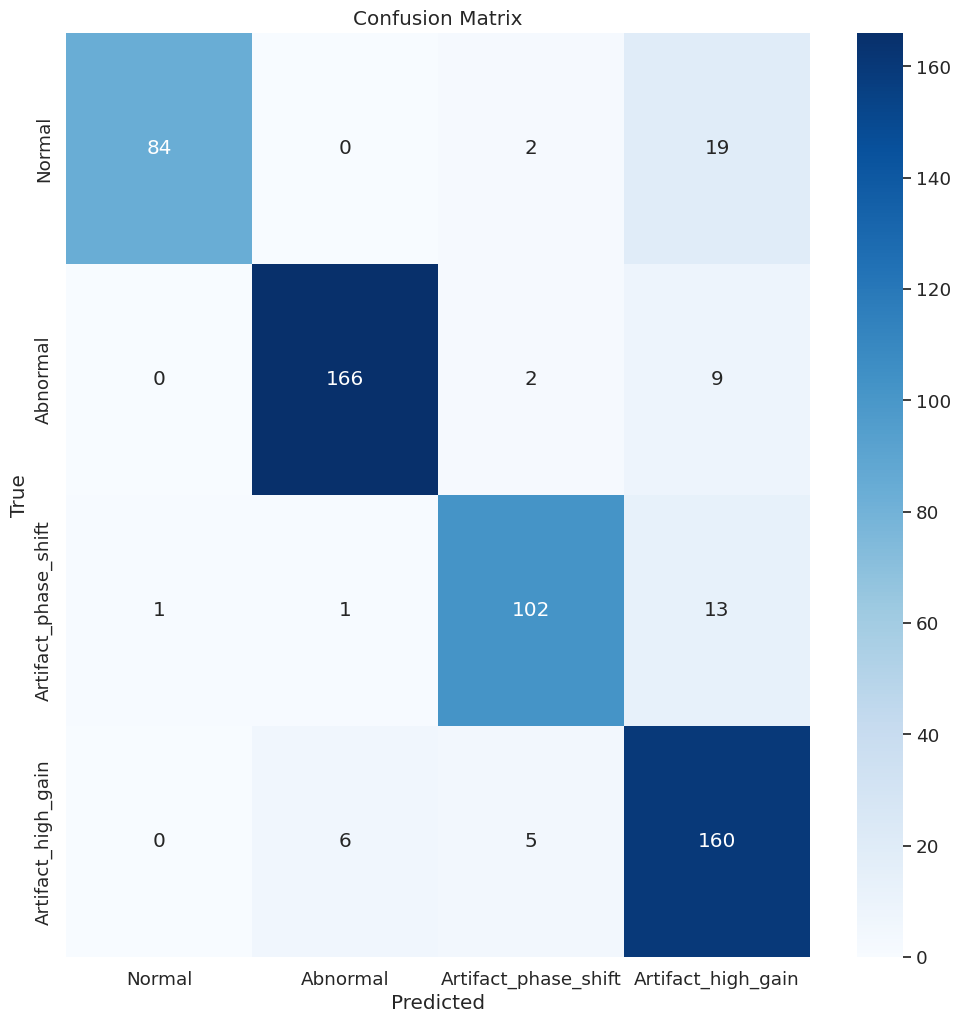

                      precision    recall  f1-score   support

              Normal       0.99      0.80      0.88       105
            Abnormal       0.96      0.94      0.95       177
Artifact_phase_shift       0.92      0.87      0.89       117
  Artifact_high_gain       0.80      0.94      0.86       171

            accuracy                           0.90       570
           macro avg       0.92      0.89      0.90       570
        weighted avg       0.91      0.90      0.90       570



In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, confusion_matrix
np.random.seed(42)
LABELS = ['Normal', 'Abnormal', 'Artifact_phase_shift', 'Artifact_high_gain']

file_data = "/content/drive/My Drive/_left_ready.csv"
file_labels = "/content/drive/My Drive/_labels_ready_new.csv"

BATCH_SIZE = 128
NUM_EPOCH = 100
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class CustomDataset(Dataset):
    def __init__(self, data, labels):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]



def read_data(data_filename, label_filename):
    features = 2
    try:
        df = pd.read_csv(data_filename)
        df_labels = pd.read_csv(label_filename)
    except FileNotFoundError:
        print("File not found. Please check the file path.")
        return None

    impulse = []
    data = np.asarray(df)
    label = np.asarray(df_labels)

    # Multi-label binarization
    mlb = MultiLabelBinarizer()
    classes = mlb.fit_transform(label)
    num_of_subclasses = len(mlb.classes_)
    for (i, label) in enumerate(mlb.classes_):
        print("{}. {}".format(i + 1, label))

    # Preprocessing
    input_size = data.shape[1] - 125
    shape = input_size * features
    eye = data[range(0, data.shape[0], 2)]
    head = data[range(1, data.shape[0], 2)]

    eye50 = [item3[25:75] for item3 in eye]
    head50 = [item4[25:75] for item4 in head]

    for i in range(len(eye)):
        impulseEye = np.asarray(eye50[i])
        impulseHead = np.asarray(head50[i])
        impulse.append([impulseEye, impulseHead])

    segments = np.asarray(impulse, dtype=np.float32).reshape(-1, input_size, features)
    segments = segments.reshape(segments.shape[0], shape)

    return segments, classes, shape, input_size, num_of_subclasses, mlb

class ConvNet(nn.Module):
    def __init__(self, input_shape, class_num):
        super(ConvNet, self).__init__()

        self.input_shape = input_shape

        self.conv1 = nn.Conv1d(in_channels=1, out_channels=50, kernel_size=5)
        self.conv2 = nn.Conv1d(in_channels=50, out_channels=50, kernel_size=5)
        self.conv3 = nn.Conv1d(in_channels=50, out_channels=100, kernel_size=5)
        self.conv4 = nn.Conv1d(in_channels=100, out_channels=100, kernel_size=5)
        self.pool = nn.MaxPool1d(kernel_size=3)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(100, class_num)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.global_pool(x).squeeze(-1)
        x = self.dropout(x)
        x = self.fc(x)

        return x



def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    model.to(DEVICE)
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {running_loss / len(train_loader):.4f}")

        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == torch.argmax(labels, dim=1)).sum().item()
                total += labels.size(0)
        val_acc = correct / total
        print(f"Validation Loss: {val_loss / len(val_loader):.4f}, Validation Accuracy: {val_acc:.4f}")

def plot_confusion_matrix(true_labels, pred_labels):
    sns.set(font_scale=1.2)
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(12, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=LABELS, yticklabels=LABELS)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()


segments, labels, input_shape, time_period, class_num, mlb = read_data(file_data, file_labels)
if segments is not None:
    x_train, x_test, y_train, y_test = train_test_split(segments, labels, test_size=0.15, random_state=42)
    print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
    print(f"x_test shape: {x_test.shape}, y_test shape: {y_test.shape}")


    sample_dataset = CustomDataset(x_train[:10], y_train[:10])
    print(sample_dataset[0])  #  return (data, label)




    train_dataset = CustomDataset(x_train, y_train)
    test_dataset = CustomDataset(x_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    model = ConvNet(input_shape, class_num)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_model(model, train_loader, val_loader, criterion, optimizer, NUM_EPOCH)

    # Evaluate model
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            y_true.extend(torch.argmax(labels, dim=1).cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    plot_confusion_matrix(y_true, y_pred)
    print(classification_report(y_true, y_pred, target_names=LABELS))

# GRAD CAM

In [24]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.hook_layers()

    def hook_layers(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def generate(self, input_tensor, target_class):
        self.model.eval()
        input_tensor = input_tensor.unsqueeze(0)  # add batch dim
        input_tensor = input_tensor.to(DEVICE)

        output = self.model(input_tensor)
        pred_class = output.argmax(dim=1).item()

        self.model.zero_grad()
        loss = output[0, target_class]
        loss.backward()

        gradients = self.gradients  # (batch, channels, time_steps)
        activations = self.activations  # (batch, channels, time_steps)

        weights = gradients.mean(dim=2, keepdim=True)  # (batch, channels, 1)
        cam = (weights * activations).sum(dim=1)  # (batch, time_steps)
        cam = torch.relu(cam)
        cam = cam.squeeze(0).cpu().numpy()

        cam = (cam - cam.min()) / (cam.max() - cam.min())
        return cam


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


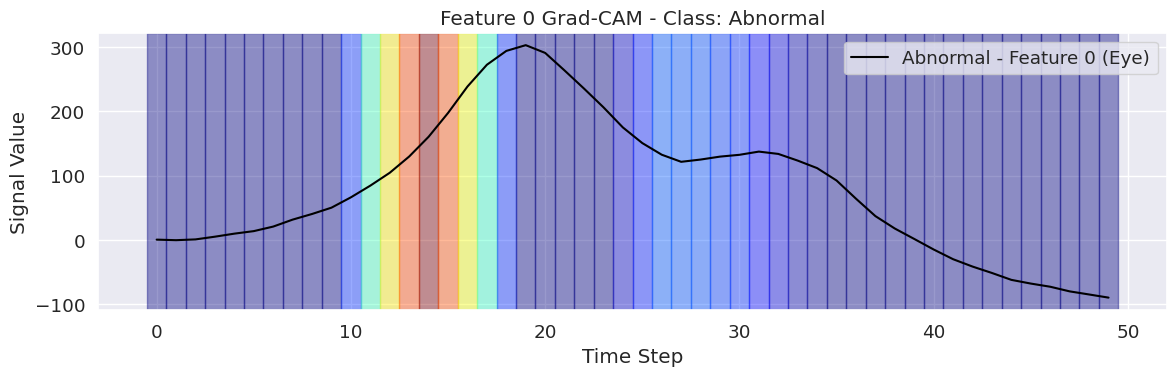

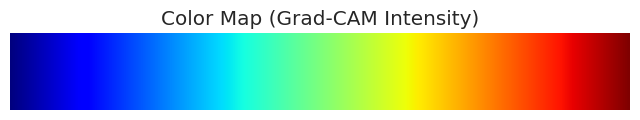

In [25]:
    sample_idx = 0
    sample_input = torch.tensor(x_test[sample_idx], dtype=torch.float32).to(DEVICE)
    sample_label = torch.argmax(torch.tensor(y_test[sample_idx])).item()
    gradcam = GradCAM(model, model.conv4)
    cam = gradcam.generate(sample_input, target_class=sample_label)

    feature_data = x_test[sample_idx][:50]
    cam_resized = np.interp(np.linspace(0, len(cam) - 1, num=50), np.arange(len(cam)), cam)
    cam_norm = (cam_resized - cam_resized.min()) / (cam_resized.max() - cam_resized.min())

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(feature_data, label=f'{LABELS[sample_label]} - Feature 0 (Eye)', color='black')
    for t in range(50):
        ax.axvspan(t - 0.5, t + 0.5, color=plt.cm.jet(cam_norm[t]), alpha=0.4)
    ax.set_title(f"Feature 0 Grad-CAM - Class: {LABELS[sample_label]}")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Signal Value")
    ax.legend()
    plt.tight_layout()
    plt.show()

    gradient = np.linspace(0, 1, 256).reshape(1, -1)
    gradient = np.vstack([gradient, gradient])
    fig, ax = plt.subplots(figsize=(8, 1))
    ax.imshow(gradient, aspect='auto', cmap='jet')
    ax.set_title('Color Map (Grad-CAM Intensity)')
    ax.set_axis_off()
    plt.show()

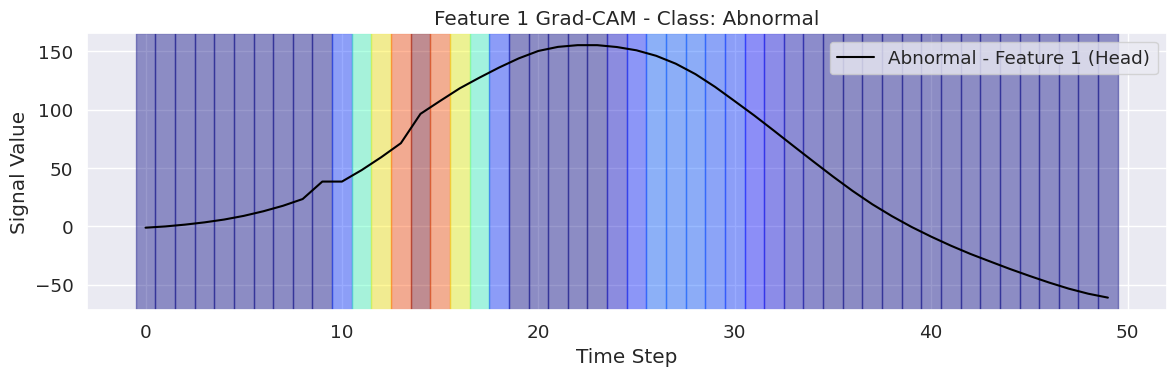

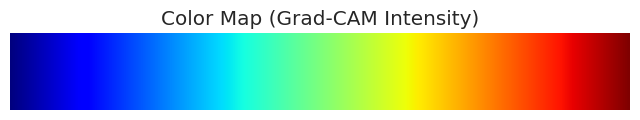

In [26]:
sample_idx = 0
sample_input = torch.tensor(x_test[sample_idx], dtype=torch.float32).to(DEVICE)
sample_label = torch.argmax(torch.tensor(y_test[sample_idx])).item()
gradcam = GradCAM(model, model.conv4)
cam = gradcam.generate(sample_input, target_class=sample_label)

feature_data_head = x_test[sample_idx][50:100]

cam_resized = np.interp(np.linspace(0, len(cam) - 1, num=50), np.arange(len(cam)), cam)
cam_norm = (cam_resized - cam_resized.min()) / (cam_resized.max() - cam_resized.min())

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(feature_data_head, label=f'{LABELS[sample_label]} - Feature 1 (Head)', color='black')
for t in range(50):
    ax.axvspan(t - 0.5, t + 0.5, color=plt.cm.jet(cam_norm[t]), alpha=0.4)
ax.set_title(f"Feature 1 Grad-CAM - Class: {LABELS[sample_label]}")
ax.set_xlabel("Time Step")
ax.set_ylabel("Signal Value")
ax.legend()
plt.tight_layout()
plt.show()

gradient = np.linspace(0, 1, 256).reshape(1, -1)
gradient = np.vstack([gradient, gradient])
fig, ax = plt.subplots(figsize=(8, 1))
ax.imshow(gradient, aspect='auto', cmap='jet')
ax.set_title('Color Map (Grad-CAM Intensity)')
ax.set_axis_off()
plt.show()

# Стандартизация данных

1. Abnormal
2. Artifact_high_gain
3. Artifact_phase_shift
4. Normal


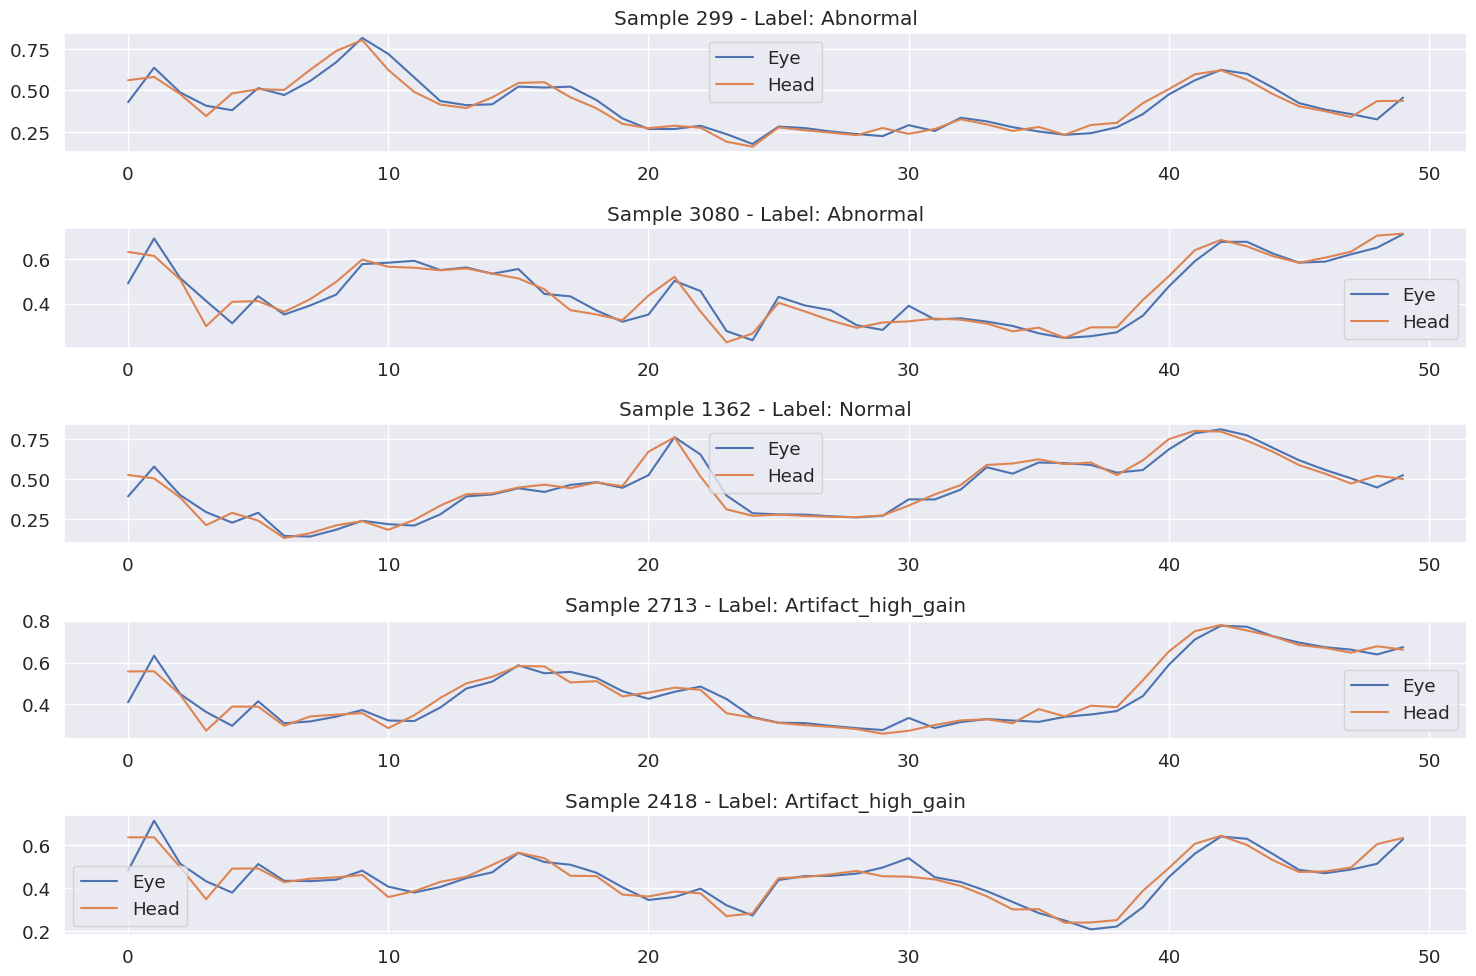

In [27]:
from sklearn.preprocessing import MinMaxScaler, MultiLabelBinarizer
import matplotlib.pyplot as plt


segments, classes, shape, input_size, num_of_subclasses, mlb = read_data(file_data, file_labels)

scaler = MinMaxScaler(feature_range=(0, 1))
segments_normalized = scaler.fit_transform(segments.reshape(segments.shape[0], -1))


features = 2  # Eye and Head
input_size = 50  # Time steps
segments_normalized = segments_normalized.reshape(-1, input_size, features)


num_samples_to_plot = 5
random_indices = np.random.choice(len(segments_normalized), num_samples_to_plot, replace=False)

plt.figure(figsize=(15, 10))

for i, idx in enumerate(random_indices):
    plt.subplot(num_samples_to_plot, 1, i + 1)
    plt.plot(segments_normalized[idx, :, 0], label='Eye')
    plt.plot(segments_normalized[idx, :, 1], label='Head')
    plt.title(f'Sample {idx + 1} - Label: {LABELS[np.argmax(classes[idx])]}')
    plt.legend()
    plt.savefig('norm.pdf')
plt.tight_layout()
plt.show()

In [79]:
num_samples = segments_normalized.shape[0]
num_features = segments_normalized.shape[1] * segments_normalized.shape[2]  # time_steps * features
X_flattened = segments_normalized.reshape(num_samples, num_features)

Размеры данных:
X_train: (2657, 100), y_train: (2657, 4)
X_val: (570, 100), y_val: (570, 4)
X_test: (570, 100), y_test: (570, 4)



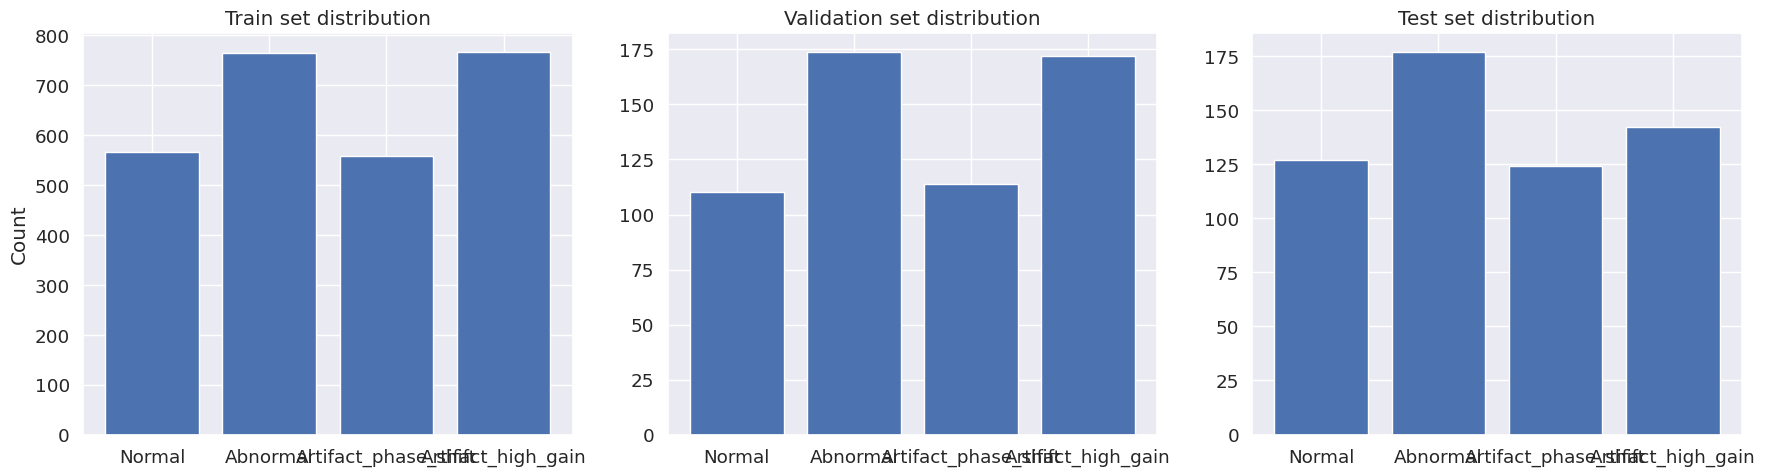

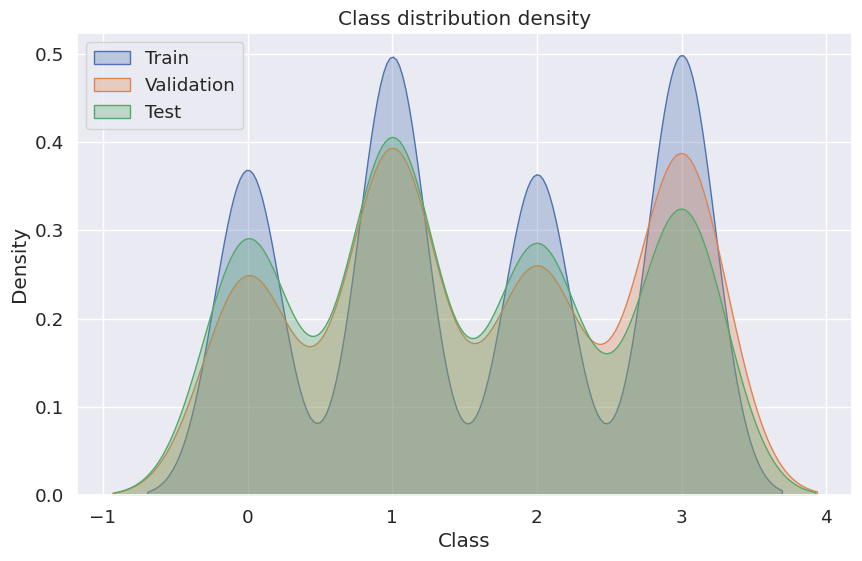

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


X_train, X_temp, y_train, y_temp = train_test_split(
    X_flattened, y, test_size=0.3, random_state=42
)
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Размеры данных:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}\n")

def plot_class_distribution(y_train, y_val, y_test, labels):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    y_train_classes = np.argmax(y_train, axis=1)
    y_val_classes = np.argmax(y_val, axis=1)
    y_test_classes = np.argmax(y_test, axis=1)

    train_counts = np.bincount(y_train_classes)
    val_counts = np.bincount(y_val_classes)
    test_counts = np.bincount(y_test_classes)

    ax1.bar(labels, train_counts)
    ax1.set_title('Train set distribution')
    ax1.set_ylabel('Count')

    ax2.bar(labels, val_counts)
    ax2.set_title('Validation set distribution')

    ax3.bar(labels, test_counts)
    ax3.set_title('Test set distribution')

    plt.tight_layout()
    plt.show()

    # Density plot
    plt.figure(figsize=(10, 6))
    sns.kdeplot(y_train_classes, label='Train', fill=True, alpha=0.3)
    sns.kdeplot(y_val_classes, label='Validation', fill=True, alpha=0.3)
    sns.kdeplot(y_test_classes, label='Test', fill=True, alpha=0.3)
    plt.title('Class distribution density')
    plt.xlabel('Class')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.show()


plot_class_distribution(y_train, y_val, y_test, LABELS)

# PCA

Explained variance ratio: [0.2867812  0.22103965]


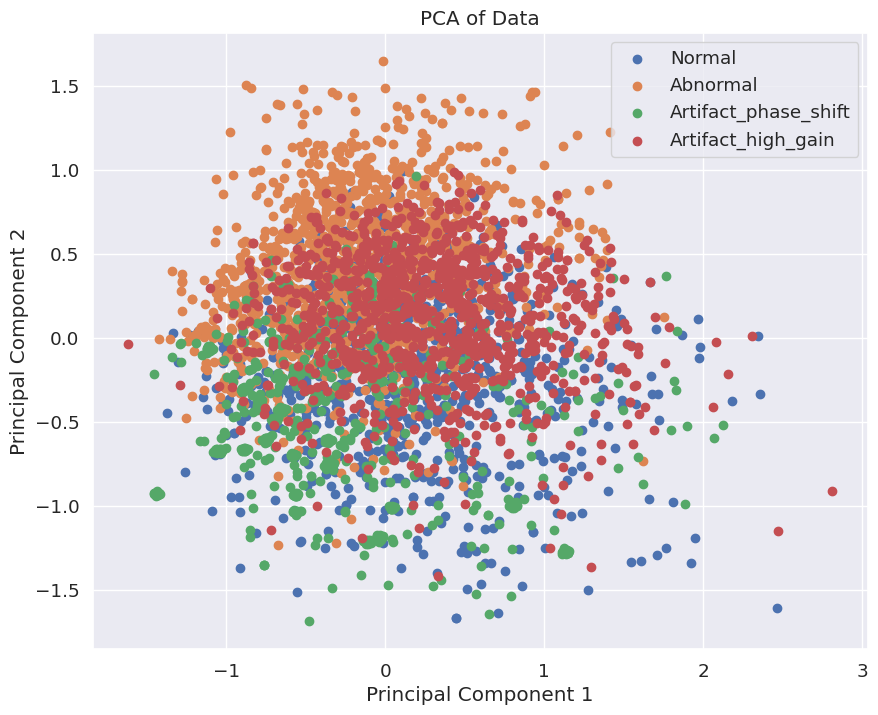

In [29]:
from sklearn.decomposition import PCA

LABELS = ['Normal', 'Abnormal', 'Artifact_phase_shift', 'Artifact_high_gain']

num_samples = segments_normalized.shape[0]
num_features = segments_normalized.shape[1] * segments_normalized.shape[2]  # time_steps * features
X_flattened = segments_normalized.reshape(num_samples, num_features)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_flattened)


print("Explained variance ratio:", pca.explained_variance_ratio_)


labels = np.argmax(classes, axis=1)


plt.figure(figsize=(10, 8))
for i, label in enumerate(LABELS):
    plt.scatter(X_pca[labels == i, 0], X_pca[labels == i, 1], label=label)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Data')
plt.legend()
plt.show()

# UMAP

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


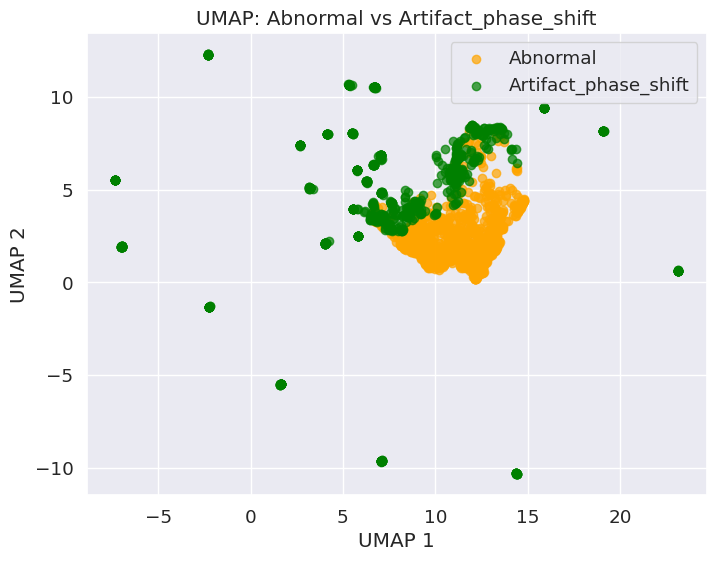

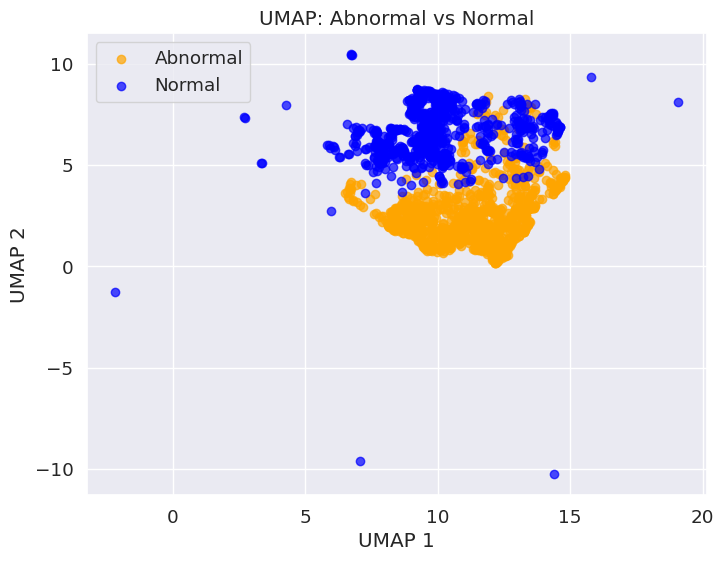

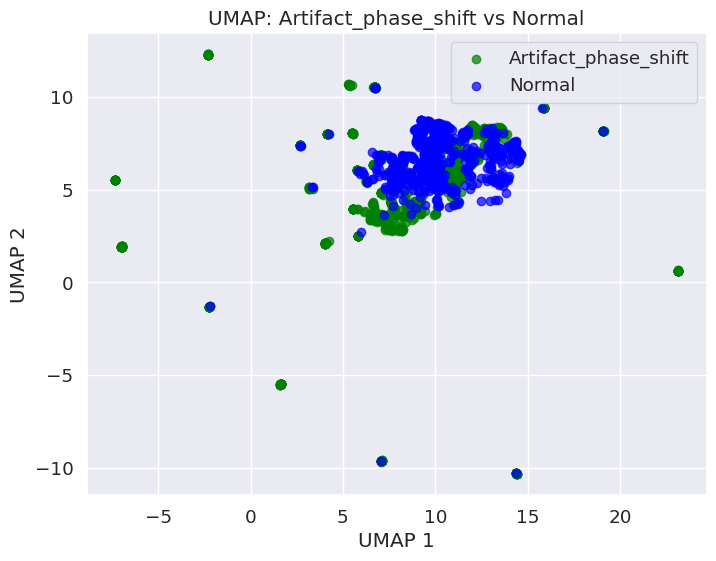

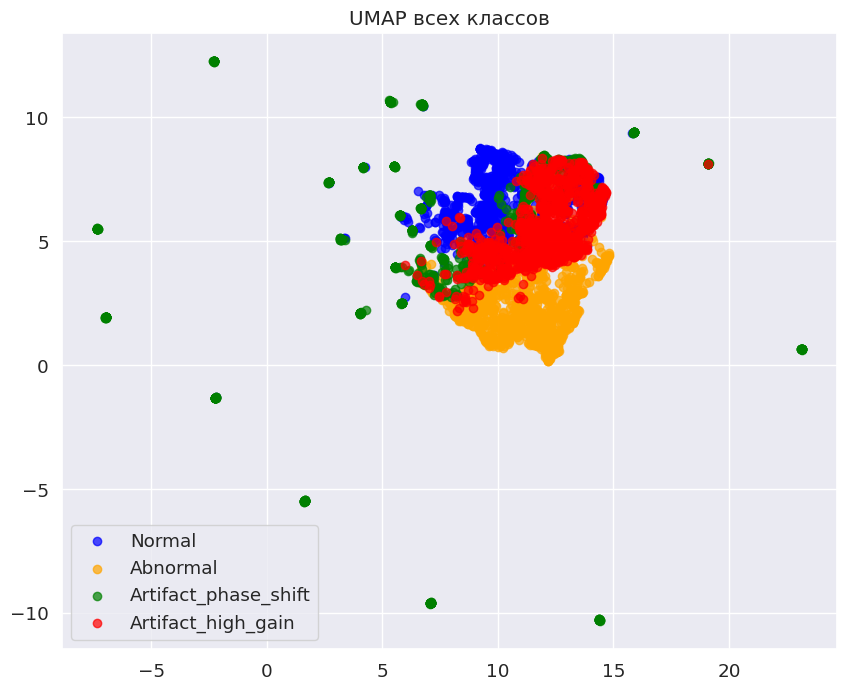

In [30]:
import umap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler


scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X_flattened)


reducer = umap.UMAP(random_state=42)
X_umap = reducer.fit_transform(X_normalized)


labels = np.argmax(classes, axis=1)


colors = ['blue', 'orange', 'green', 'red']


def plot_umap_pairs(X_umap, labels, class_pairs):
    for pair in class_pairs:
        plt.figure(figsize=(8, 6))

        mask = np.isin(labels, pair)
        X_filtered = X_umap[mask]
        labels_filtered = labels[mask]

        for class_idx in pair:
            plt.scatter(X_filtered[labels_filtered == class_idx, 0],
                       X_filtered[labels_filtered == class_idx, 1],
                       color=colors[class_idx],
                       label=LABELS[class_idx],
                       alpha=0.7)

        plt.title(f'UMAP: {LABELS[pair[0]]} vs {LABELS[pair[1]]}')
        plt.xlabel('UMAP 1')
        plt.ylabel('UMAP 2')
        plt.legend()
        plt.show()


class_pairs = [
    [1, 2],  # Abnormal (оранжевый) vs Artifact_phase_shift (зелёный)
    [1, 0],  # Abnormal (оранжевый) vs Normal (синий)
    [2, 0]   # Artifact_phase_shift (зелёный) vs Normal (синий)
]


plot_umap_pairs(X_umap, labels, class_pairs)


plt.figure(figsize=(10, 8))
for i, label in enumerate(LABELS):
    plt.scatter(X_umap[labels == i, 0], X_umap[labels == i, 1],
               color=colors[i], label=label, alpha=0.7)
plt.title('UMAP всех классов')
plt.legend()
plt.show()

## Бинарная классификация


In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split


X_train_list = []
y_train_list = []


train_pairs = [[1, 2], [1, 0]]

for pair in train_pairs:
    mask = np.isin(labels, pair)
    X_pair = X_umap[mask]
    y_pair = labels[mask]

    y_pair_mapped = np.array([0 if l == pair[0] else 1 for l in y_pair])

    X_train_list.append(X_pair)
    y_train_list.append(y_pair_mapped)


X_train = np.vstack(X_train_list)
y_train = np.hstack(y_train_list)
X_tr, X_te, y_tr, y_te = train_test_split(X_train, y_train, test_size=0.3, random_state=42)


rf = RandomForestClassifier(random_state=42)
rf.fit(X_tr, y_tr)


y_pred = rf.predict(X_te)
print(classification_report(y_te, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       688
           1       0.99      0.95      0.97       462

    accuracy                           0.97      1150
   macro avg       0.98      0.97      0.97      1150
weighted avg       0.97      0.97      0.97      1150



## Классификация по всем 4 классам

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split


X = X_umap
y = labels


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)


y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=LABELS))

                      precision    recall  f1-score   support

              Normal       0.83      0.84      0.83       237
            Abnormal       0.96      0.86      0.91       351
Artifact_phase_shift       0.81      0.79      0.80       238
  Artifact_high_gain       0.74      0.84      0.79       314

            accuracy                           0.84      1140
           macro avg       0.84      0.83      0.83      1140
        weighted avg       0.84      0.84      0.84      1140



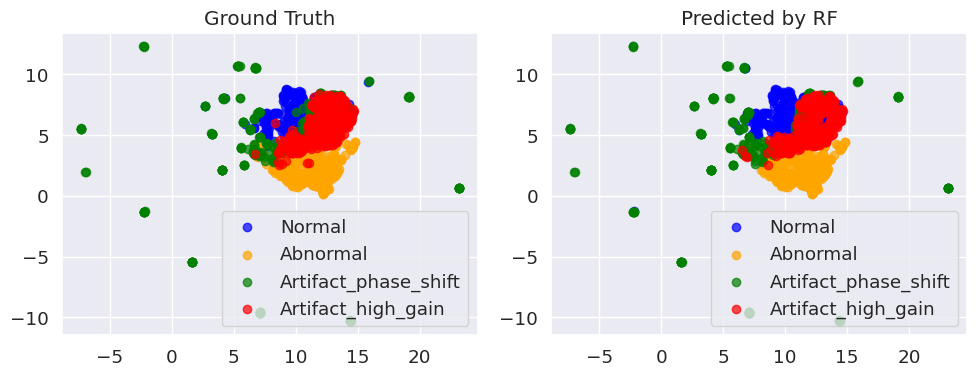

In [33]:
import matplotlib.pyplot as plt

# True
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
for i, label in enumerate(LABELS):
    plt.scatter(X_test[y_test == i, 0], X_test[y_test == i, 1],
                color=colors[i], label=label, alpha=0.7)
plt.title("Ground Truth")
plt.legend()

# Predicted
plt.subplot(1, 2, 2)
for i, label in enumerate(LABELS):
    plt.scatter(X_test[y_pred == i, 0], X_test[y_pred == i, 1],
                color=colors[i], label=label, alpha=0.7)
plt.title("Predicted by RF")
plt.legend()

plt.tight_layout()
plt.show()

# Takens embeddings


In [34]:
def takens_embedding(data, m=5, tau=1):
    """
    data: numpy array  (samples, time, features)
    out: numpy array (samples, timesteps, m * features)
    """
    N, T, F = data.shape
    T_new = T - (m - 1) * tau

    if T_new <= 0:
        raise ValueError("Time series too short for given m and tau")

    embedded = []
    for t in range(T_new):
        chunk = []
        for k in range(m):
            chunk.append(data[:, t + k * tau, :])
        chunk = np.concatenate(chunk, axis=1)
        embedded.append(chunk)

    embedded = np.stack(embedded, axis=1)
    return embedded

In [35]:
X_takens = takens_embedding(segments_normalized, m=5, tau=1)
X_flattened = X_takens.reshape(X_takens.shape[0], -1)
y = np.argmax(classes, axis=1)

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X_flattened, y, test_size=0.3, random_state=42)

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=LABELS))

                      precision    recall  f1-score   support

              Normal       1.00      0.92      0.95       237
            Abnormal       0.98      0.96      0.97       351
Artifact_phase_shift       0.93      0.94      0.93       238
  Artifact_high_gain       0.90      0.96      0.93       314

            accuracy                           0.95      1140
           macro avg       0.95      0.94      0.95      1140
        weighted avg       0.95      0.95      0.95      1140



## Визуализация неверно классифицированных 5%

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


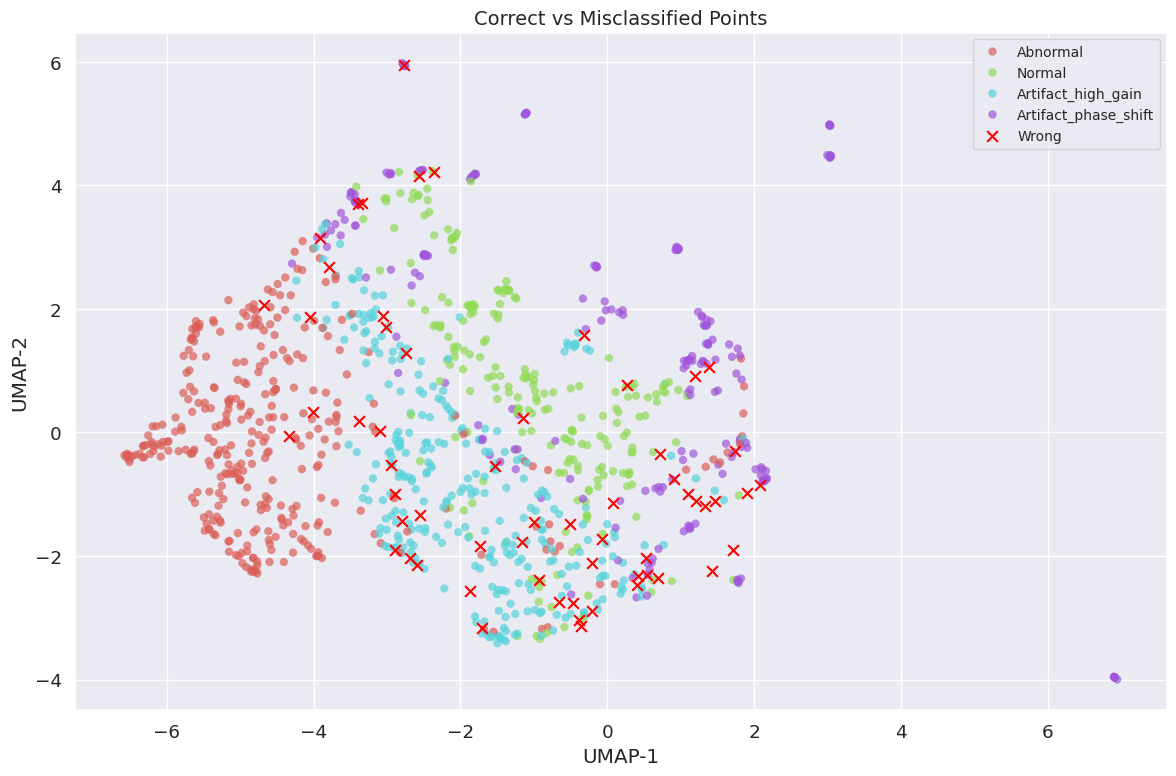

In [37]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns


reducer = umap.UMAP(random_state=42)
X_umap = reducer.fit_transform(X_test)


correct_mask = y_test == y_pred
wrong_mask = ~correct_mask


palette = sns.color_palette("hls", len(LABELS))


plt.figure(figsize=(12, 8))

sns.scatterplot(x=X_umap[correct_mask, 0], y=X_umap[correct_mask, 1],
                hue=[LABELS[i] for i in y_test[correct_mask]],
                palette=palette, alpha=0.7, edgecolor="none", marker='o')


plt.scatter(X_umap[wrong_mask, 0], X_umap[wrong_mask, 1],
            c='red', marker='x', label='Wrong', s=60)

plt.legend(loc='best', fontsize=10)
plt.title("Correct vs Misclassified Points", fontsize=14)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# wrong_indices = np.where(y_pred != y_test)[0]
# print(len(wrong_indices))

# num_to_plot = 5


# for idx in wrong_indices[:num_to_plot]:
#     sample = X_test[idx]
#     true_label = y_test[idx]
#     pred_label = y_pred[idx]


#     timesteps = (sample.shape[0]) // (5 * 2)  # 5 is m (Takens embedding), 2 is features
#     sample_reshaped = sample.reshape(timesteps, 5 * 2)


#     plt.figure(figsize=(12, 4))
#     for i in range(2):  # Eye and Head
#         plt.plot(sample_reshaped[:, i::2], label=f'Feature {i} (every 2nd col)')

#     plt.title(f"Misclassified Sample {idx}: True = {LABELS[true_label]}, Predicted = {LABELS[pred_label]}")
#     plt.xlabel('Time step (approximate)')
#     plt.ylabel('Signal value')
#     plt.legend()
#     plt.grid(True)
#     plt.show()

## OPTUNA (long wait)

In [38]:
pip install optuna

In [39]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

def objective(trial):
    m = trial.suggest_int('m', 2, 10)
    tau = trial.suggest_int('tau', 1, 5)

    try:
        X_embedded = takens_embedding(segments_normalized, m=m, tau=tau)
    except ValueError:
        return 0.0

    X_flat = X_embedded.reshape(X_embedded.shape[0], -1)

    model = RandomForestClassifier(random_state=42, n_jobs=-1)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_flat, y, cv=cv, scoring='accuracy', n_jobs=-1)

    return scores.mean()


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)


print("Best m and tau:")
print(study.best_params)

best_m = study.best_params['m']
best_tau = study.best_params['tau']


X_best = takens_embedding(segments_normalized, m=best_m, tau=best_tau)
X_flat_best = X_best.reshape(X_best.shape[0], -1)

X_train, X_test, y_train, y_test = train_test_split(X_flat_best, y, test_size=0.3, random_state=42, stratify=y)

final_model = RandomForestClassifier(random_state=42, n_jobs=-1)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=LABELS))

[I 2025-06-01 17:04:28,968] A new study created in memory with name: no-name-96194ccd-8141-47a4-855a-5f068a44954d
[I 2025-06-01 17:05:09,334] Trial 0 finished with value: 0.9444324249358574 and parameters: {'m': 9, 'tau': 3}. Best is trial 0 with value: 0.9444324249358574.
[I 2025-06-01 17:05:36,134] Trial 1 finished with value: 0.9473302822273073 and parameters: {'m': 4, 'tau': 5}. Best is trial 1 with value: 0.9473302822273073.
[I 2025-06-01 17:06:02,680] Trial 2 finished with value: 0.947328548644338 and parameters: {'m': 7, 'tau': 5}. Best is trial 1 with value: 0.9473302822273073.
[I 2025-06-01 17:06:42,656] Trial 3 finished with value: 0.9457489078427294 and parameters: {'m': 10, 'tau': 2}. Best is trial 1 with value: 0.9473302822273073.
[I 2025-06-01 17:07:06,461] Trial 4 finished with value: 0.9457489078427294 and parameters: {'m': 7, 'tau': 3}. Best is trial 1 with value: 0.9473302822273073.
[I 2025-06-01 17:07:23,992] Trial 5 finished with value: 0.9486446848346162 and parame

Best m and tau:
{'m': 2, 'tau': 3}
                      precision    recall  f1-score   support

              Normal       0.99      0.93      0.96       241
            Abnormal       0.97      0.96      0.97       335
Artifact_phase_shift       0.93      0.94      0.93       239
  Artifact_high_gain       0.90      0.95      0.92       325

            accuracy                           0.94      1140
           macro avg       0.95      0.94      0.94      1140
        weighted avg       0.95      0.94      0.94      1140



In [40]:
import xgboost as xgb
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics import classification_report

best_m = 2
best_tau = 3


X_best = takens_embedding(segments_normalized, m=best_m, tau=best_tau)
X_flat_best = X_best.reshape(X_best.shape[0], -1)


X_train, X_test, y_train, y_test = train_test_split(X_flat_best, y, test_size=0.3, random_state=42, stratify=y)


final_model = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_jobs=-1
)

final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)


print(classification_report(y_test, y_pred, target_names=LABELS))

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:21:10] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


                      precision    recall  f1-score   support

              Normal       1.00      0.94      0.97       241
            Abnormal       0.98      0.96      0.97       335
Artifact_phase_shift       0.94      0.95      0.95       239
  Artifact_high_gain       0.91      0.96      0.93       325

            accuracy                           0.95      1140
           macro avg       0.96      0.95      0.95      1140
        weighted avg       0.96      0.95      0.95      1140



## SMOTE on Takens + class weights

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
import numpy as np


X_takens = takens_embedding(segments_normalized, m=3, tau=4)
X_flattened = X_takens.reshape(X_takens.shape[0], -1)
y = np.argmax(classes, axis=1)


X_train, X_test, y_train, y_test = train_test_split(X_flattened, y, test_size=0.3, random_state=42, stratify=y)

# Вычисление весов классов
classes_unique = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes_unique, y=y_train)
class_weight_dict = dict(zip(classes_unique, class_weights))
print("Class weights:", class_weight_dict)

# Обучение модели с учетом веса классов
clf = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=LABELS))


Class weights: {np.int64(0): np.float64(1.1798401420959148), np.int64(1): np.float64(0.8516025641025641), np.int64(2): np.float64(1.1904121863799284), np.int64(3): np.float64(0.8786375661375662)}
                      precision    recall  f1-score   support

              Normal       0.98      0.92      0.95       241
            Abnormal       0.98      0.96      0.97       335
Artifact_phase_shift       0.92      0.94      0.93       239
  Artifact_high_gain       0.91      0.95      0.93       325

            accuracy                           0.94      1140
           macro avg       0.95      0.94      0.94      1140
        weighted avg       0.95      0.94      0.94      1140



<ipython-input-43-cf1cdf26ef98>:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar", class_names=LABELS)


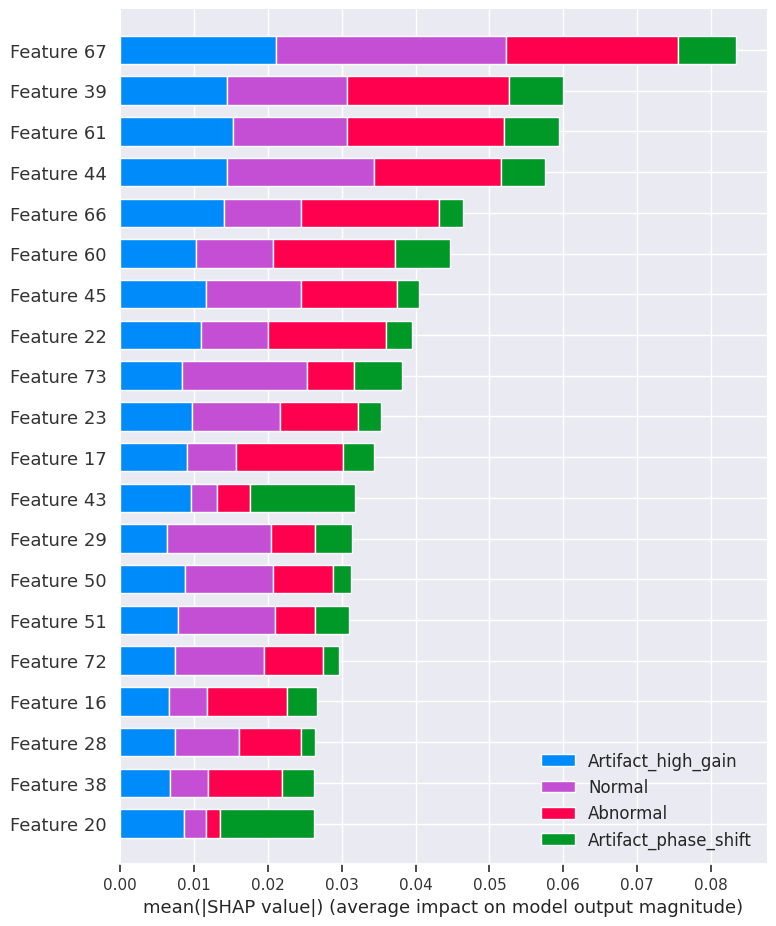

<ipython-input-43-cf1cdf26ef98>:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=[f"feat_{i}" for i in range(X_flattened.shape[1])])
/usr/local/lib/python3.11/dist-packages/shap/plots/_beeswarm.py:726: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.11/dist-packages/shap/plots/_beeswarm.py:746: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/l

<Figure size 640x480 with 0 Axes>

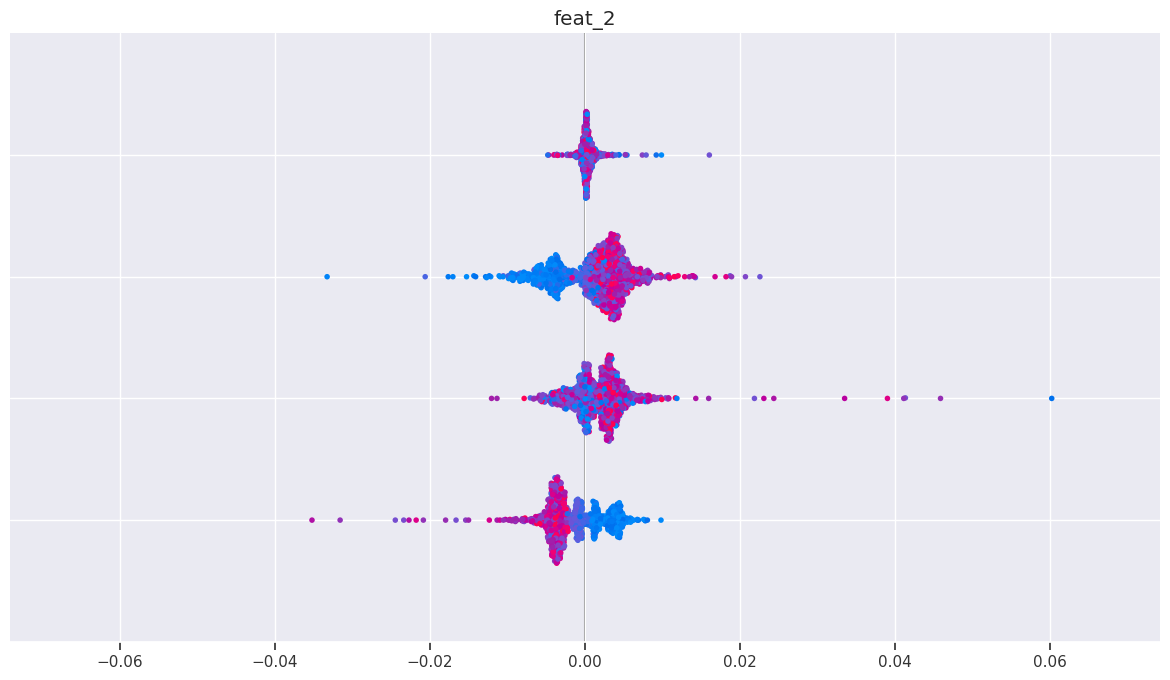

In [43]:
import shap
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar", class_names=LABELS)
shap.summary_plot(shap_values, X_test, feature_names=[f"feat_{i}" for i in range(X_flattened.shape[1])])


## Simple CNN with 2 layers

In [44]:
import torch
import torch.nn as nn

class TimeSeriesCNN(nn.Module):
    def __init__(self, input_channels, num_classes):
        super(TimeSeriesCNN, self).__init__()
        self.conv1 = nn.Conv1d(input_channels, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.global_pool(x)
        x = x.squeeze(-1)
        x = self.fc(x)
        return x

In [45]:
import torch
from torchsummary import summary

input_channels = 10
num_classes = 5
model = TimeSeriesCNN(input_channels, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

summary(model, input_size=(input_channels, 10))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1               [-1, 32, 10]             992
              ReLU-2               [-1, 32, 10]               0
            Conv1d-3               [-1, 64, 10]           6,208
              ReLU-4               [-1, 64, 10]               0
 AdaptiveAvgPool1d-5                [-1, 64, 1]               0
            Linear-6                    [-1, 5]             325
Total params: 7,525
Trainable params: 7,525
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 0.03
Estimated Total Size (MB): 0.04
----------------------------------------------------------------


In [47]:
best_m = 2
best_tau = 3

X_best = takens_embedding(segments_normalized, m=best_m, tau=best_tau)


X_train, X_test, y_train, y_test = train_test_split(
    X_best, y, test_size=0.3, random_state=42, stratify=y
)


X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)


In [48]:
import torch
from sklearn.metrics import classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TimeSeriesCNN(input_channels=X_best.shape[2], num_classes=len(LABELS)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


for epoch in range(300):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {running_loss/len(train_loader):.4f}")



model.eval()


with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
    outputs = model(X_test_tensor)
    preds = torch.argmax(outputs, dim=1).cpu().numpy()

print(classification_report(y_test, preds, target_names=LABELS))

Epoch 1 Loss: 1.3747
Epoch 2 Loss: 1.3580
Epoch 3 Loss: 1.3392
Epoch 4 Loss: 1.3183
Epoch 5 Loss: 1.3009
Epoch 6 Loss: 1.2812
Epoch 7 Loss: 1.2647
Epoch 8 Loss: 1.2586
Epoch 9 Loss: 1.2451
Epoch 10 Loss: 1.2350
Epoch 11 Loss: 1.2264
Epoch 12 Loss: 1.2181
Epoch 13 Loss: 1.2086
Epoch 14 Loss: 1.1933
Epoch 15 Loss: 1.1805
Epoch 16 Loss: 1.1705
Epoch 17 Loss: 1.1626
Epoch 18 Loss: 1.1579
Epoch 19 Loss: 1.1470
Epoch 20 Loss: 1.1451
Epoch 21 Loss: 1.1305
Epoch 22 Loss: 1.1238
Epoch 23 Loss: 1.1154
Epoch 24 Loss: 1.1101
Epoch 25 Loss: 1.1098
Epoch 26 Loss: 1.1015
Epoch 27 Loss: 1.1016
Epoch 28 Loss: 1.0952
Epoch 29 Loss: 1.0855
Epoch 30 Loss: 1.0885
Epoch 31 Loss: 1.0848
Epoch 32 Loss: 1.0885
Epoch 33 Loss: 1.0788
Epoch 34 Loss: 1.0734
Epoch 35 Loss: 1.0755
Epoch 36 Loss: 1.0644
Epoch 37 Loss: 1.0669
Epoch 38 Loss: 1.0686
Epoch 39 Loss: 1.0570
Epoch 40 Loss: 1.0560
Epoch 41 Loss: 1.0647
Epoch 42 Loss: 1.0581
Epoch 43 Loss: 1.0566
Epoch 44 Loss: 1.0504
Epoch 45 Loss: 1.0502
Epoch 46 Loss: 1.05

## kNN classifier with dtw (dynamic time wrapping)

In [49]:
pip install tslearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 28.1 MB/s eta 0:00:00


long wait

In [50]:
from sklearn.model_selection import train_test_split
from tslearn.neighbors import KNeighborsTimeSeriesClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X_takens, y, test_size=0.2, random_state=42)


knn_dtw = KNeighborsTimeSeriesClassifier(n_neighbors=3, metric="dtw", n_jobs=-1)

knn_dtw.fit(X_train, y_train)

y_pred = knn_dtw.predict(X_test)

print(classification_report(y_test, y_pred, target_names=LABELS))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


                      precision    recall  f1-score   support

              Normal       0.96      0.90      0.93       150
            Abnormal       0.98      0.89      0.93       237
Artifact_phase_shift       0.89      0.87      0.88       152
  Artifact_high_gain       0.83      0.95      0.89       221

            accuracy                           0.91       760
           macro avg       0.91      0.90      0.91       760
        weighted avg       0.91      0.91      0.91       760



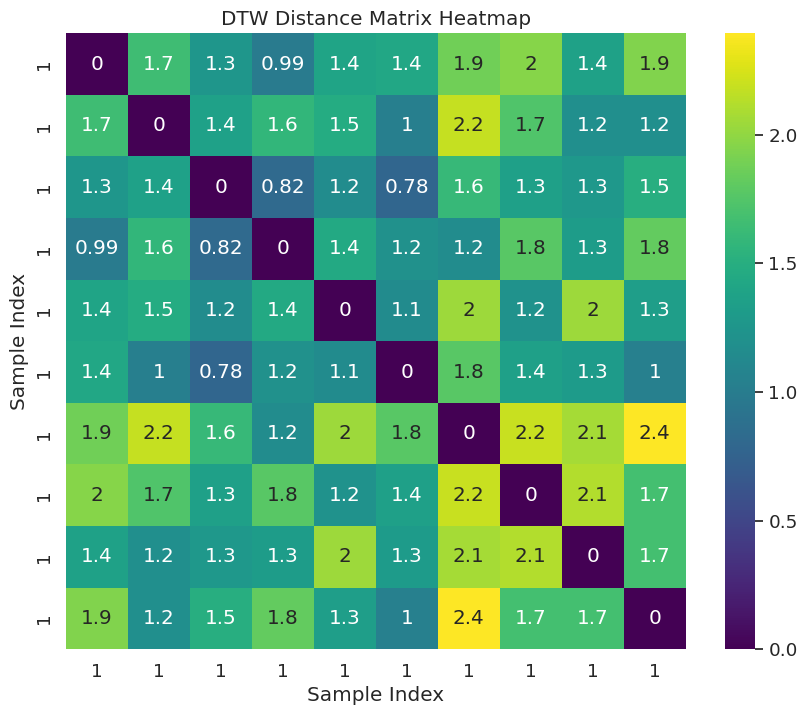

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
from tslearn.metrics import cdist_dtw

X_vis = X_takens[:10]
y_vis = y[:10]

# distances
dtw_matrix = cdist_dtw(X_vis)


plt.figure(figsize=(10, 8))
sns.heatmap(dtw_matrix, xticklabels=y_vis, yticklabels=y_vis, annot=True, cmap="viridis")
plt.title("DTW Distance Matrix Heatmap")
plt.xlabel("Sample Index")
plt.ylabel("Sample Index")
plt.show()


# Сегментация рядов + старые признаки

In [52]:
pip install ruptures

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 58.7 MB/s eta 0:00:00


In [53]:
import numpy as np
import pandas as pd
import pywt
import ruptures as rpt
from scipy.fft import fft
from scipy.stats import skew, kurtosis
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report


def takens_embedding(signal, m=3, tau=4):
    N = len(signal)
    return np.array([signal[i:i + m * tau:tau] for i in range(N - (m - 1) * tau)]).flatten()[:150]


def wavelet_summary(signal, wavelet='db4', level=3):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    features = []
    for coeff in coeffs:
        features.extend([np.mean(coeff), np.var(coeff), np.sum(coeff**2)])
    return features


def segment_stats(signal, max_segments=5):
    algo = rpt.Pelt(model="rbf").fit(signal)
    change_points = algo.predict(pen=5)
    segments = np.split(signal, change_points[:-1])
    features = []
    for seg in segments[:max_segments]:
        if len(seg) > 1:
            features.extend([np.mean(seg), np.std(seg), np.sum(seg**2), len(seg)])
    while len(features) < max_segments * 4:
        features.append(0.0)
    features.extend([len(segments), np.mean([len(s) for s in segments])])
    return features


def global_stats(signal):
    grad = np.gradient(signal)
    return [
        np.max(signal), np.min(signal),
        np.argmax(signal) - np.argmin(signal),
        grad[np.argmax(grad)],
        np.mean(signal), np.var(signal),
        skew(signal), kurtosis(signal)
    ]


def fft_features(signal, n=5):
    spectrum = np.abs(fft(signal))[1:]
    return np.log1p(spectrum[:n]).tolist()



def extract_features(signal):
    features = []
    features.extend(takens_embedding(signal))
    features.extend(wavelet_summary(signal))
    features.extend(segment_stats(signal))
    features.extend(global_stats(signal))
    features.extend(fft_features(signal))
    return features


def build_feature_matrix(signals_eye, signals_head, labels):
    feature_list = []
    for i in range(len(signals_eye)):
        eye_feat = extract_features(signals_eye[i])
        head_feat = extract_features(signals_head[i])
        full_feat = np.concatenate([eye_feat, head_feat])
        feature_list.append(full_feat)
    X = np.stack(feature_list)
    y = np.argmax(labels, axis=1)
    return X, y



In [54]:
import pandas as pd
import numpy as np

file_data = "/content/drive/My Drive/_left_ready.csv"
file_labels = "/content/drive/My Drive/_labels_ready_new.csv"

df = pd.read_csv(file_data)
df_labels = pd.read_csv(file_labels)

data = np.asarray(df)
labels = np.asarray(df_labels)

min_samples = min(len(data), len(labels))
data = data[:min_samples]
labels = labels[:min_samples]


from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labels_encoded = le.fit_transform(labels.ravel())


signals_eye = data[0::2]
signals_head = data[1::2]


num_samples = min(len(signals_eye), len(signals_head))
signals_eye = signals_eye[:num_samples]
signals_head = signals_head[:num_samples]
labels_encoded = labels_encoded[:num_samples]


feature_list = []
for i in range(num_samples):
    eye_feat = extract_features(signals_eye[i])
    head_feat = extract_features(signals_head[i])
    combined = np.concatenate([eye_feat, head_feat])
    feature_list.append(combined)

X = np.vstack(feature_list)
y = labels_encoded

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.9543859649122807
                      precision    recall  f1-score   support

            Abnormal       0.95      1.00      0.97       110
  Artifact_high_gain       0.96      1.00      0.98       160
Artifact_phase_shift       0.67      0.25      0.36         8
              Normal       0.00      0.00      0.00         7

            accuracy                           0.95       285
           macro avg       0.64      0.56      0.58       285
        weighted avg       0.93      0.95      0.94       285



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<ipython-input-55-a271440348ce>:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar", class_names=le.classes_)


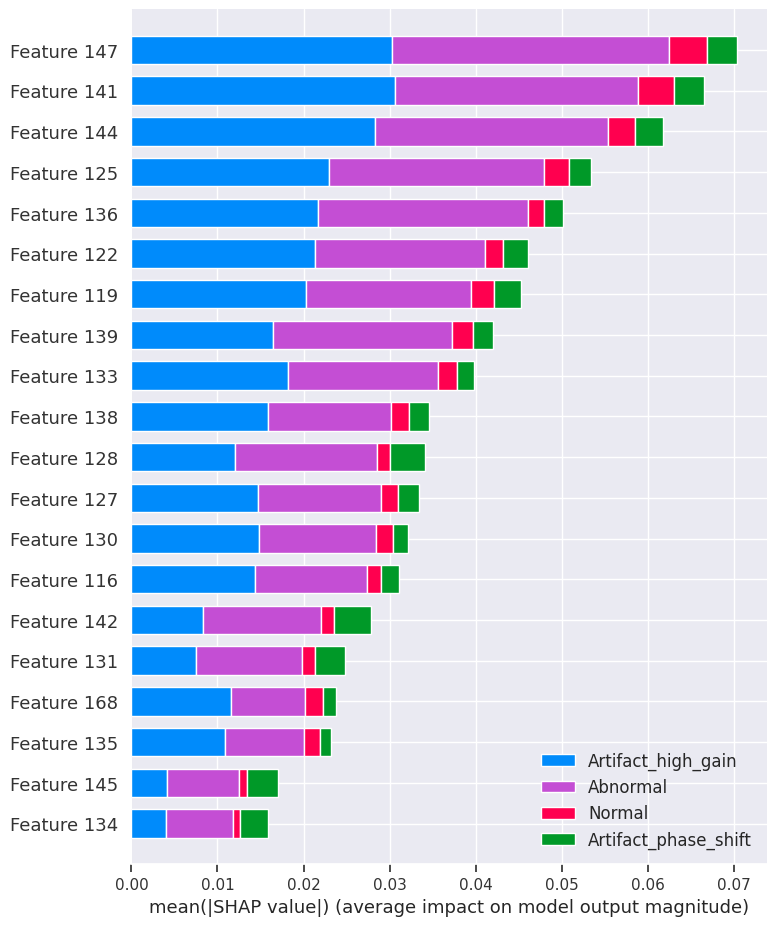

<ipython-input-55-a271440348ce>:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=[f"feat_{i}" for i in range(X.shape[1])])
/usr/local/lib/python3.11/dist-packages/shap/plots/_beeswarm.py:726: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.11/dist-packages/shap/plots/_beeswarm.py:746: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3

<Figure size 640x480 with 0 Axes>

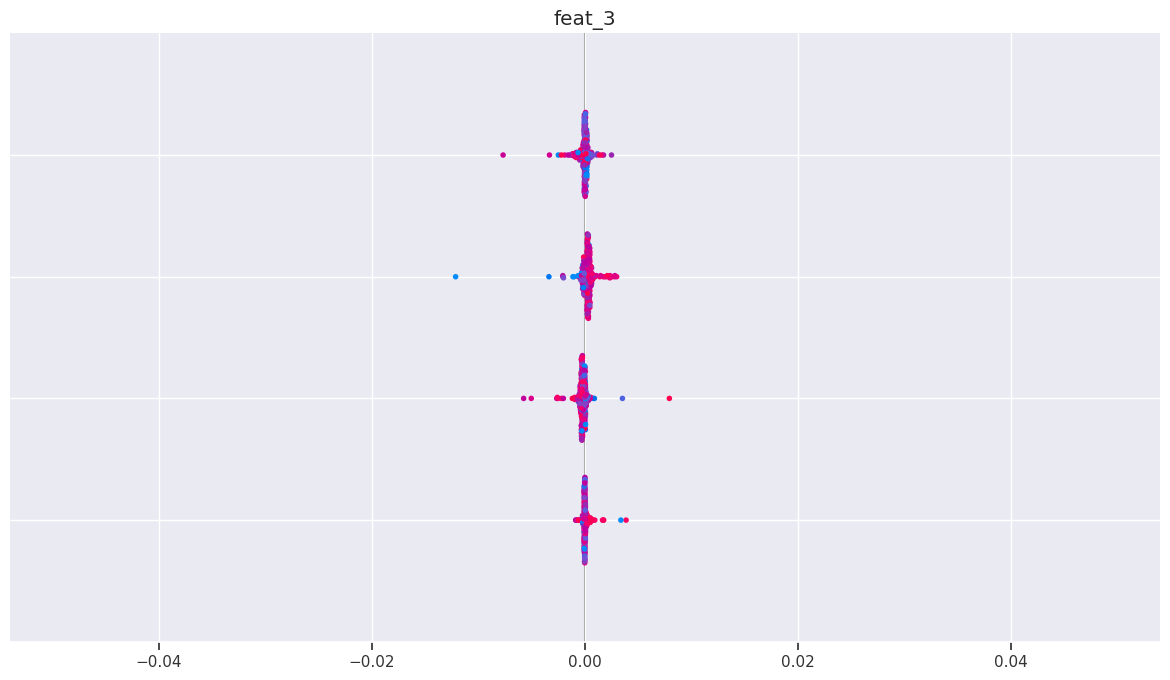

In [55]:
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar", class_names=le.classes_)
shap.summary_plot(shap_values, X_test, feature_names=[f"feat_{i}" for i in range(X.shape[1])])


In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf = XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric='mlogloss')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:42:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.9614035087719298
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       110
           1       0.98      1.00      0.99       160
           2       0.71      0.62      0.67         8
           3       0.00      0.00      0.00         7

    accuracy                           0.96       285
   macro avg       0.66      0.65      0.66       285
weighted avg       0.94      0.96      0.95       285



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<ipython-input-57-a271440348ce>:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar", class_names=le.classes_)


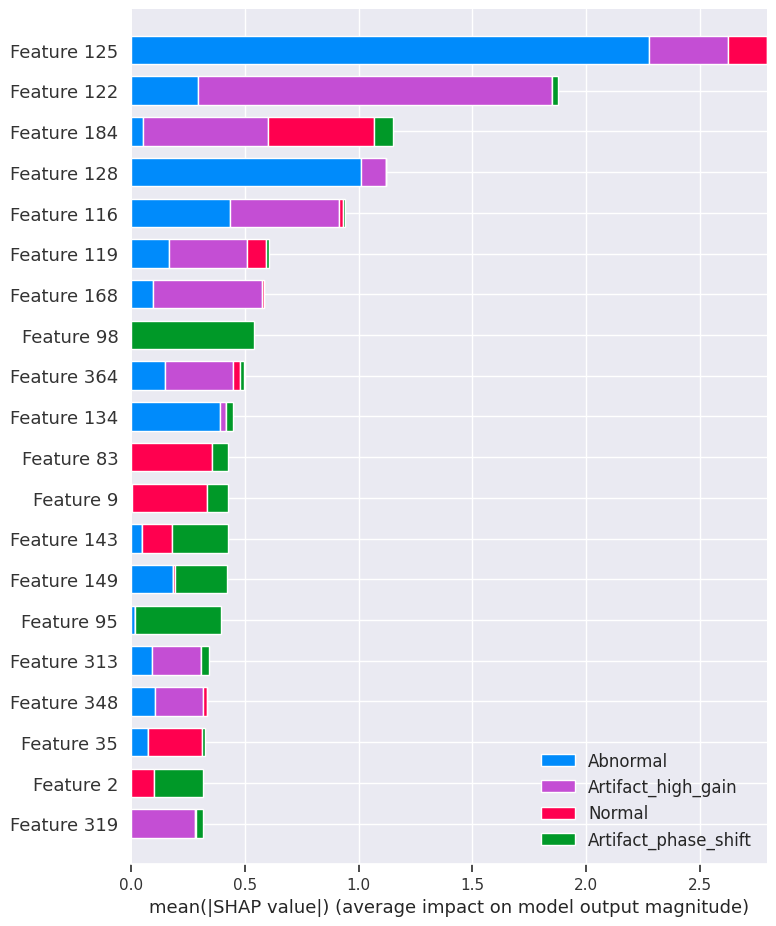

<ipython-input-57-a271440348ce>:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=[f"feat_{i}" for i in range(X.shape[1])])
/usr/local/lib/python3.11/dist-packages/shap/plots/_beeswarm.py:726: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.11/dist-packages/shap/plots/_beeswarm.py:746: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3

<Figure size 640x480 with 0 Axes>

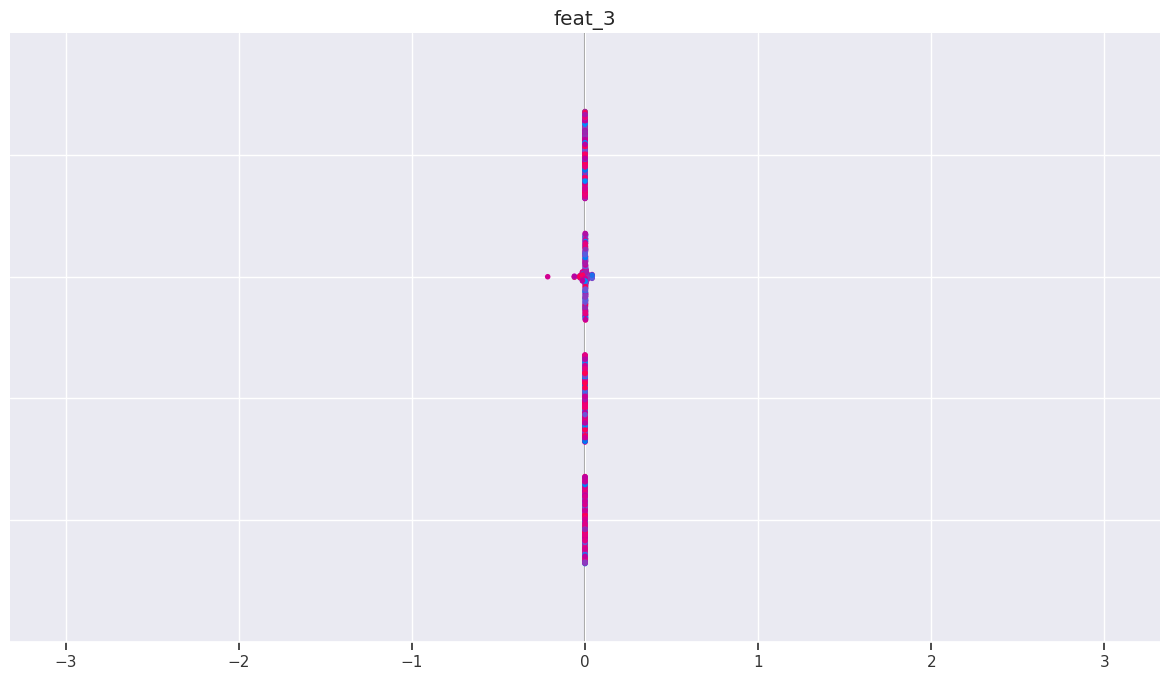

In [57]:
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar", class_names=le.classes_)
shap.summary_plot(shap_values, X_test, feature_names=[f"feat_{i}" for i in range(X.shape[1])])

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Compute class weights
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

print("Class weights:", class_weight_dict)


clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight=class_weight_dict
)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=LABELS))


Class weights: {np.int64(0): np.float64(0.5938880706921944), np.int64(1): np.float64(0.48293413173652694), np.int64(2): np.float64(8.065), np.int64(3): np.float64(8.229591836734693)}
Accuracy: 0.9438596491228071
                      precision    recall  f1-score   support

              Normal       0.93      0.99      0.96       120
            Abnormal       0.96      0.99      0.98       147
Artifact_phase_shift       1.00      0.22      0.36         9
  Artifact_high_gain       0.67      0.22      0.33         9

            accuracy                           0.94       285
           macro avg       0.89      0.61      0.66       285
        weighted avg       0.94      0.94      0.93       285



In [60]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

clf.fit(X_train_resampled, y_train_resampled)
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=LABELS))

Accuracy: 0.9228070175438596
                      precision    recall  f1-score   support

              Normal       0.95      0.97      0.96       120
            Abnormal       0.95      0.97      0.96       147
Artifact_phase_shift       0.57      0.44      0.50         9
  Artifact_high_gain       0.14      0.11      0.12         9

            accuracy                           0.92       285
           macro avg       0.65      0.62      0.64       285
        weighted avg       0.91      0.92      0.92       285



In [61]:
import xgboost as xgb

clf = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='mlogloss',
    scale_pos_weight=class_weights
)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=LABELS))

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:43:49] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.9578947368421052
                      precision    recall  f1-score   support

              Normal       0.95      0.99      0.97       120
            Abnormal       0.97      1.00      0.99       147
Artifact_phase_shift       1.00      0.44      0.62         9
  Artifact_high_gain       0.60      0.33      0.43         9

            accuracy                           0.96       285
           macro avg       0.88      0.69      0.75       285
        weighted avg       0.95      0.96      0.95       285



# Feature extraction

## RF

In [62]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


def extract_features(data):
    features = []
    for signal in data:
        signal = np.asarray(signal).flatten()

        peak_height = np.max(signal)
        peak_width = np.argmax(signal) - np.argmin(signal)
        max_velocity_slope = np.gradient(signal)[np.argmax(np.gradient(signal))]

        mean = np.mean(signal)
        variance = np.var(signal)
        skewness = pd.Series(signal).skew() # Коэффициент асимметрии
        kurtosis = pd.Series(signal).kurtosis() # Коэффициент эксцесса (хвостиковости)

        features.append([peak_height, peak_width, max_velocity_slope, mean, variance, skewness, kurtosis])
    return np.array(features)


file_data = "/content/drive/My Drive/_left_ready.csv"
file_labels = "/content/drive/My Drive/_labels_ready_new.csv"

df = pd.read_csv(file_data)
df_labels = pd.read_csv(file_labels)

data = np.asarray(df)
labels = np.asarray(df_labels)


min_samples = min(len(data), len(labels))
data = data[:min_samples]
labels = labels[:min_samples]
labels = labels.ravel()

features = extract_features(data)


print("Features shape:", features.shape)
print("Labels shape:", labels.shape)


X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.15, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=LABELS))

Features shape: (3797, 7)
Labels shape: (3797,)
Accuracy: 0.4263157894736842
                      precision    recall  f1-score   support

              Normal       0.33      0.34      0.33       105
            Abnormal       0.46      0.50      0.48       177
Artifact_phase_shift       0.39      0.38      0.38       117
  Artifact_high_gain       0.48      0.44      0.46       171

            accuracy                           0.43       570
           macro avg       0.41      0.41      0.41       570
        weighted avg       0.43      0.43      0.43       570



## SVM

In [63]:
from sklearn.svm import SVC

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.15, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=LABELS))

Accuracy: 0.41228070175438597
                      precision    recall  f1-score   support

              Normal       0.30      0.06      0.10       105
            Abnormal       0.40      0.68      0.51       177
Artifact_phase_shift       0.45      0.13      0.20       117
  Artifact_high_gain       0.43      0.54      0.48       171

            accuracy                           0.41       570
           macro avg       0.40      0.35      0.32       570
        weighted avg       0.40      0.41      0.36       570



In [64]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1, 5], 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'linear', 'poly']}
grid_search = GridSearchCV(SVC(), param_grid, cv=5)
grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)

Best parameters: {'C': 5, 'gamma': 'scale', 'kernel': 'rbf'}


In [65]:
clf = SVC(kernel='rbf', C=5, gamma='scale', random_state=42)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=LABELS))

Accuracy: 0.3929824561403509
                      precision    recall  f1-score   support

              Normal       0.32      0.17      0.22       105
            Abnormal       0.39      0.56      0.46       177
Artifact_phase_shift       0.39      0.17      0.24       117
  Artifact_high_gain       0.42      0.50      0.46       171

            accuracy                           0.39       570
           macro avg       0.38      0.35      0.34       570
        weighted avg       0.39      0.39      0.37       570



## SVM signal features + Fourier

In [66]:
def extract_features_Forier(data):
    features = []
    for signal in data:
        signal = np.asarray(signal).flatten()

        peak_height = np.max(signal)
        peak_width = np.argmax(signal) - np.argmin(signal)
        max_velocity_slope = np.gradient(signal)[np.argmax(np.gradient(signal))]
        mean = np.mean(signal)
        variance = np.var(signal)
        skewness = pd.Series(signal).skew()
        kurtosis = pd.Series(signal).kurtosis()

        fft_values = np.fft.fft(signal)
        magnitude_spectrum = np.abs(fft_values)
        dominant_frequency = np.argmax(magnitude_spectrum)
        mean_freq = np.mean(magnitude_spectrum)
        var_freq = np.var(magnitude_spectrum)

        features.append([
            peak_height, peak_width, max_velocity_slope, mean, variance, skewness, kurtosis,
            dominant_frequency, mean_freq, var_freq
        ])
    return np.array(features)


features = extract_features_Forier(data)


print("Features shape:", features.shape)
print("Labels shape:", labels.shape)


X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.15, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=LABELS))

Features shape: (3797, 10)
Labels shape: (3797,)
Accuracy: 0.4105263157894737
                      precision    recall  f1-score   support

              Normal       0.33      0.09      0.14       105
            Abnormal       0.41      0.65      0.50       177
Artifact_phase_shift       0.46      0.15      0.23       117
  Artifact_high_gain       0.41      0.54      0.47       171

            accuracy                           0.41       570
           macro avg       0.40      0.36      0.33       570
        weighted avg       0.41      0.41      0.37       570



## Random forest signal features + Fourier

In [67]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=LABELS))

Accuracy: 0.42105263157894735
                      precision    recall  f1-score   support

              Normal       0.33      0.32      0.33       105
            Abnormal       0.46      0.50      0.48       177
Artifact_phase_shift       0.39      0.33      0.36       117
  Artifact_high_gain       0.46      0.46      0.46       171

            accuracy                           0.42       570
           macro avg       0.41      0.40      0.40       570
        weighted avg       0.42      0.42      0.42       570



In [68]:
def extract_features_Forier_only(data):
    features = []
    for signal in data:
        signal = np.asarray(signal).flatten()
        fft_values = np.fft.fft(signal)
        magnitude_spectrum = np.abs(fft_values)
        dominant_frequency = np.argmax(magnitude_spectrum)
        mean_freq = np.mean(magnitude_spectrum)
        var_freq = np.var(magnitude_spectrum)

        features.append([dominant_frequency, mean_freq, var_freq])
    return np.array(features)


features = extract_features_Forier_only(data)
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.15, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=LABELS))

Accuracy: 0.4192982456140351
                      precision    recall  f1-score   support

              Normal       0.36      0.09      0.14       105
            Abnormal       0.44      0.63      0.52       177
Artifact_phase_shift       0.36      0.11      0.17       117
  Artifact_high_gain       0.41      0.62      0.50       171

            accuracy                           0.42       570
           macro avg       0.39      0.36      0.33       570
        weighted avg       0.40      0.42      0.37       570



In [69]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=LABELS))

Accuracy: 0.4070175438596491
                      precision    recall  f1-score   support

              Normal       0.31      0.38      0.34       105
            Abnormal       0.46      0.50      0.48       177
Artifact_phase_shift       0.32      0.24      0.27       117
  Artifact_high_gain       0.47      0.44      0.45       171

            accuracy                           0.41       570
           macro avg       0.39      0.39      0.39       570
        weighted avg       0.41      0.41      0.40       570



## Wavelet transform

In [70]:
pip install PyWavelets

In [71]:
import pywt
from sklearn.svm import SVC

def extract_features_wavelet(data, wavelet='db1', level=3):
    features = []
    for signal in data:
        signal = np.asarray(signal).flatten()

        peak_height = np.max(signal)
        peak_width = np.argmax(signal) - np.argmin(signal)
        max_velocity_slope = np.gradient(signal)[np.argmax(np.gradient(signal))]
        mean = np.mean(signal)
        variance = np.var(signal)
        skewness = pd.Series(signal).skew()
        kurtosis = pd.Series(signal).kurtosis()


        coeffs = pywt.wavedec(signal, wavelet, level=level)
        wavelet_features = []
        for i, coeff in enumerate(coeffs):
            if i == 0:
                wavelet_features.append(np.mean(coeff))
                wavelet_features.append(np.var(coeff))
            else:
                wavelet_features.append(np.mean(coeff))
                wavelet_features.append(np.var(coeff))
                wavelet_features.append(np.sum(np.square(coeff)))

        features.append([
            peak_height, peak_width, max_velocity_slope, mean, variance, skewness, kurtosis,
            *wavelet_features
        ])
    return np.array(features)



features = extract_features_wavelet(data, wavelet='coif1', level=3)

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.15, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=LABELS))

Accuracy: 0.4245614035087719
                      precision    recall  f1-score   support

              Normal       0.50      0.11      0.19       105
            Abnormal       0.43      0.71      0.54       177
Artifact_phase_shift       0.41      0.12      0.19       117
  Artifact_high_gain       0.41      0.53      0.46       171

            accuracy                           0.42       570
           macro avg       0.44      0.37      0.34       570
        weighted avg       0.43      0.42      0.38       570



In [92]:
features = extract_features_wavelet(data, wavelet='coif1', level=3)

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.15, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=LABELS))

Accuracy: 0.47368421052631576
                      precision    recall  f1-score   support

            Abnormal       0.42      0.35      0.38       105
  Artifact_high_gain       0.51      0.58      0.54       177
Artifact_phase_shift       0.42      0.33      0.37       117
              Normal       0.48      0.54      0.51       171

            accuracy                           0.47       570
           macro avg       0.46      0.45      0.45       570
        weighted avg       0.47      0.47      0.47       570



# Фазовое пространство

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.integrate import simpson

def standardize_and_visualize(data, labels, mlb):
    scaler = StandardScaler()
    data_std = np.zeros_like(data)
    for i in range(data.shape[0]):
        data_std[i] = scaler.fit_transform(data[i].reshape(-1, 2)).reshape(data[i].shape)

    normal_idx = np.where(labels[:, mlb.classes_.tolist().index('Normal')])[0]
    ref_curve = data_std[normal_idx].mean(axis=0)

    plt.figure(figsize=(12, 6))

    plt.plot(ref_curve[:, 0], ref_curve[:, 1], 'k--', label='Reference (Normal)')

    for i, class_name in enumerate(mlb.classes_):
        class_idx = np.where(labels[:, i])[0]
        if len(class_idx) > 0:
            sample = data_std[class_idx[0]]
            plt.plot(sample[:, 0], sample[:, 1], label=class_name)

    plt.xlabel('Eye Velocity (standardized)')
    plt.ylabel('Head Velocity (standardized)')
    plt.title('Phase Space Trajectories')
    plt.legend()
    plt.grid(True)
    plt.show()

    return data_std, ref_curve

In [73]:
def calculate_signed_area(curve, ref_curve):
    diff = curve - ref_curve

    area = simpson(diff[:, 1], x=diff[:, 0])
    return area

def compute_areas(data_std, ref_curve):
    areas = np.zeros(data_std.shape[0])
    for i in range(data_std.shape[0]):
        areas[i] = calculate_signed_area(data_std[i], ref_curve)
    return areas

In [74]:
def extract_features(data_std, ref_curve):
    features = []
    for sample in data_std:
        velocity_diff = sample[:, 0] - sample[:, 1]
        accel = np.diff(sample, axis=0)
        area = calculate_signed_area(sample, ref_curve)
        feat = {
            'mean_eye': np.mean(sample[:, 0]),
            'std_eye': np.std(sample[:, 0]),
            'mean_head': np.mean(sample[:, 1]),
            'correlation': np.corrcoef(sample[:, 0], sample[:, 1])[0, 1],
            'signed_area': area,
            'max_diff': np.max(velocity_diff),
            'mean_accel': np.mean(accel)
        }
        features.append(list(feat.values()))

    return np.array(features)

1. Abnormal
2. Artifact_high_gain
3. Artifact_phase_shift
4. Normal


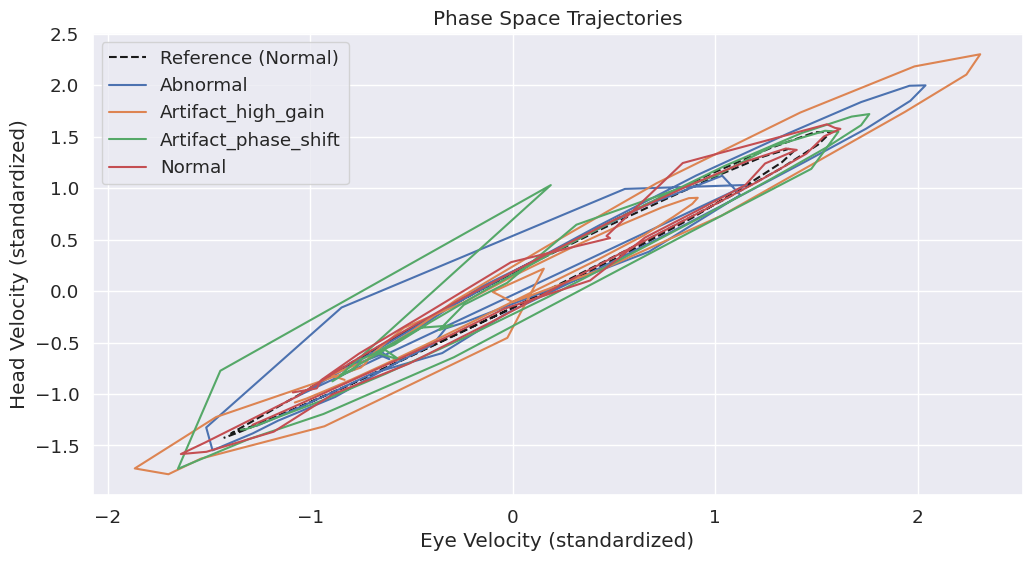

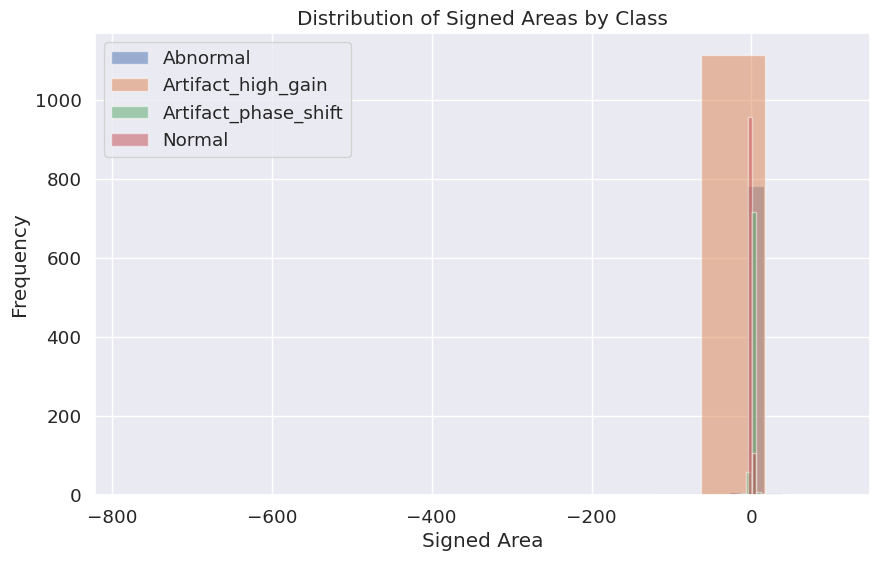

In [75]:
segments, classes, shape, input_size, num_of_subclasses, mlb = read_data(file_data, file_labels)
data_3d = segments.reshape(-1, input_size, 2)


data_std, ref_curve = standardize_and_visualize(data_3d, classes, mlb)


areas = compute_areas(data_std, ref_curve)


X = extract_features(data_std, ref_curve)
y = classes


plt.figure(figsize=(10, 6))
for i, class_name in enumerate(mlb.classes_):
    class_areas = areas[classes[:, i] == 1]
    plt.hist(class_areas, alpha=0.5, label=class_name)
plt.xlabel('Signed Area')
plt.ylabel('Frequency')
plt.title('Distribution of Signed Areas by Class')
plt.legend()
plt.show()

In [76]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


clf = RandomForestClassifier(n_estimators=100)
clf.fit(X_train, y_train)


print(f"Train accuracy: {clf.score(X_train, y_train):.2f}")
print(f"Test accuracy: {clf.score(X_test, y_test):.2f}")

Train accuracy: 1.00
Test accuracy: 0.39


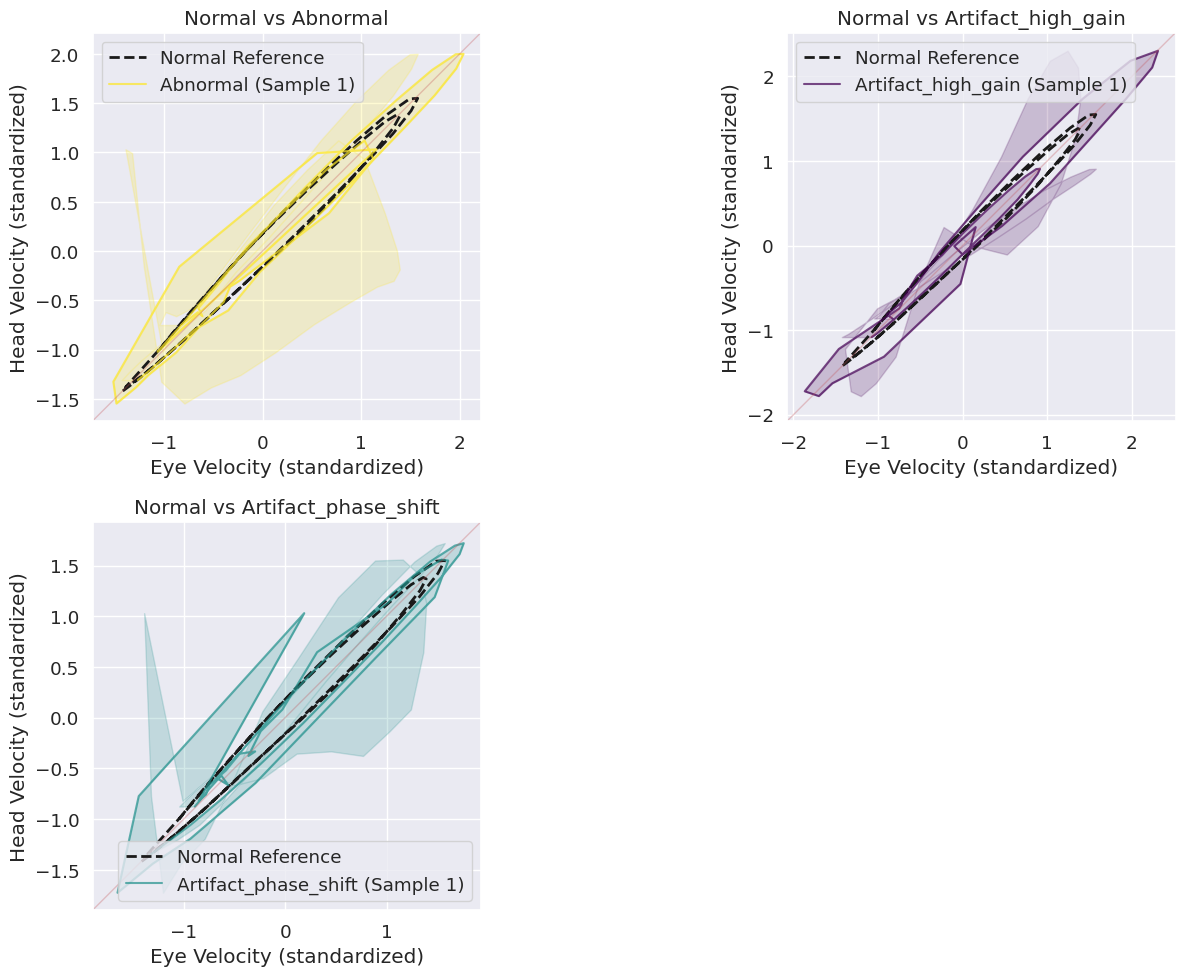

In [77]:
from matplotlib.gridspec import GridSpec

def plot_class_vs_normal_comparison(data_std, labels, mlb, ref_curve, n_samples=1):
    class_names = mlb.classes_
    normal_idx = np.where(labels[:, class_names.tolist().index('Normal')])[0]

    fig = plt.figure(figsize=(15, 10))
    gs = GridSpec(2, 2, figure=fig)

    colors = plt.cm.viridis(np.linspace(0, 1, len(class_names)-1))

    for i, class_name in enumerate(class_names):
        if class_name == 'Normal':
            continue

        ax = fig.add_subplot(gs[i//2, i%2])

        ax.plot(ref_curve[:, 0], ref_curve[:, 1],
                'k--', linewidth=2, label='Normal Reference')

        class_idx = np.where(labels[:, i])[0]
        for j in range(min(n_samples, len(class_idx))):
            sample = data_std[class_idx[j]]
            ax.plot(sample[:, 0], sample[:, 1],
                    color=colors[i-1], alpha=0.7,
                    label=f'{class_name} (Sample {j+1})')

            ax.fill_betweenx(sample[:, 1],
                            ref_curve[:, 0], sample[:, 0],
                            color=colors[i-1], alpha=0.2)

        ax.set_xlabel('Eye Velocity (standardized)')
        ax.set_ylabel('Head Velocity (standardized)')
        ax.set_title(f'Normal vs {class_name}')
        ax.legend()
        ax.grid(True)

        lims = [np.min([ax.get_xlim(), ax.get_ylim()]),
                np.max([ax.get_xlim(), ax.get_ylim()])]
        ax.plot(lims, lims, 'r-', alpha=0.3, linewidth=1)
        ax.set_aspect('equal')
        ax.set_xlim(lims)
        ax.set_ylim(lims)

    plt.tight_layout()
    plt.show()


plot_class_vs_normal_comparison(data_std, classes, mlb, ref_curve, n_samples=1)

# Площади под кривыми, площади м\у кривыми, и отдельно площади выше сигнала головы (м\у двумя сигналами) и ниже



=== Data Verification ===
Segments shape: (3797, 50, 2)
Unique labels: ['Abnormal' 'Artifact_high_gain' 'Artifact_phase_shift' 'Normal']
Numeric label counts: [ 804 1115  797 1081]


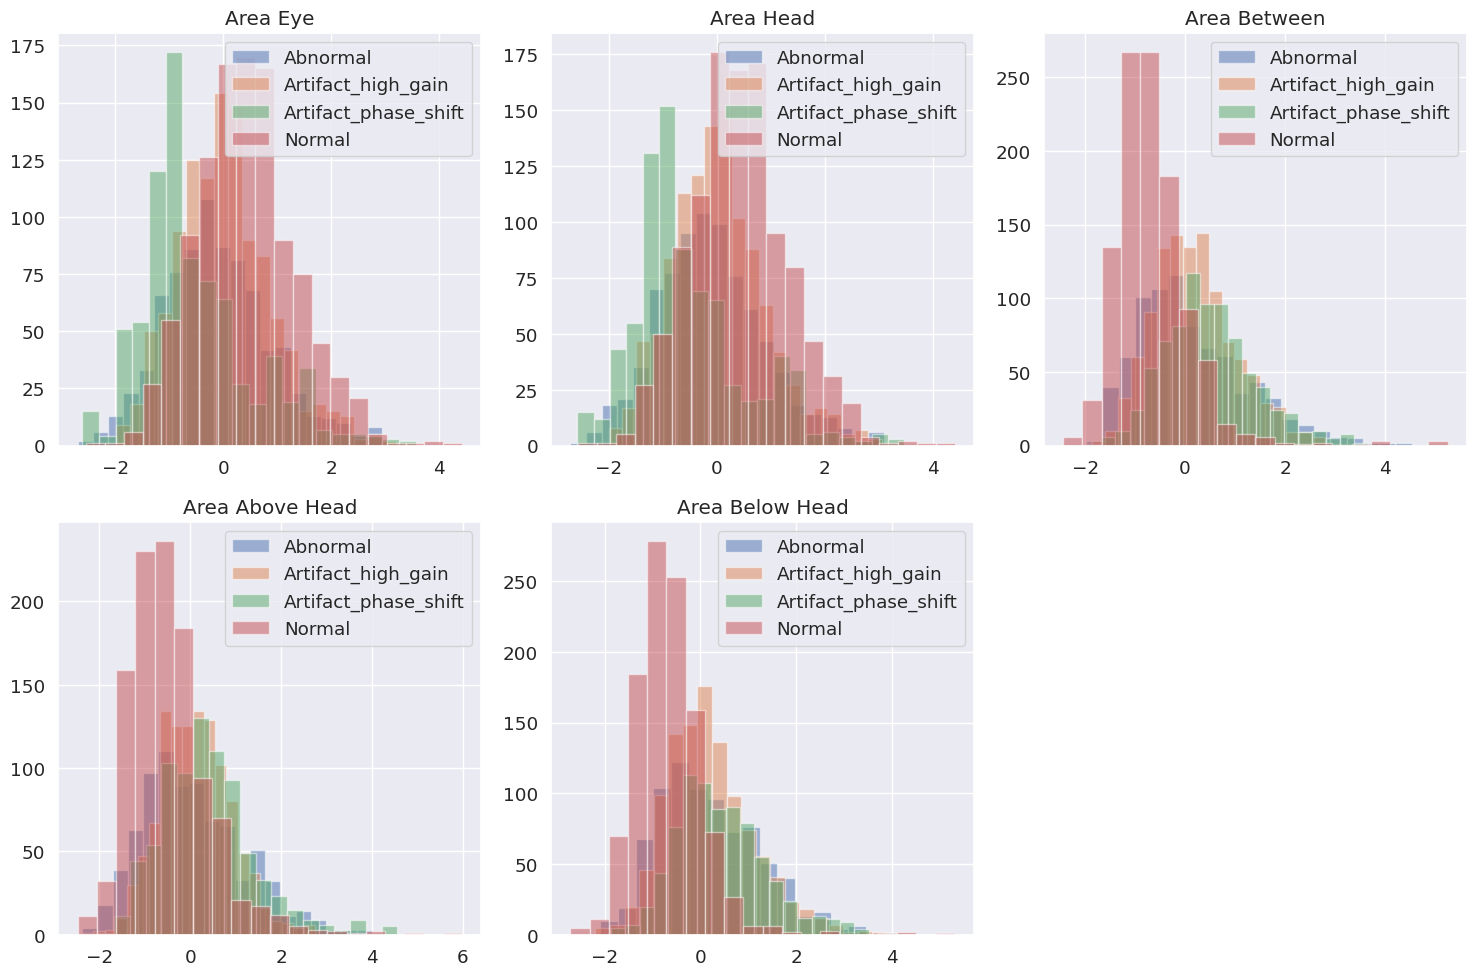

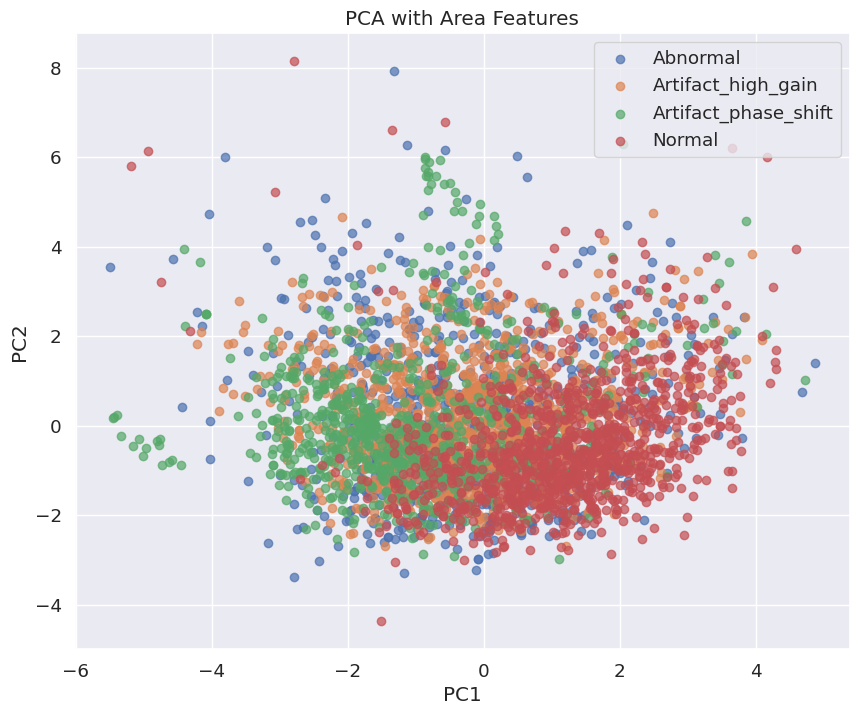

In [90]:
import numpy as np
import pandas as pd
from scipy.integrate import simpson
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

le = LabelEncoder()
numeric_labels = le.fit_transform(labels)
LABELS = le.classes_

print("\n=== Data Verification ===")
print(f"Segments shape: {segments_normalized.shape}")
print(f"Unique labels: {LABELS}")
print(f"Numeric label counts: {np.bincount(numeric_labels)}")

def calculate_areas(segments):
    features = []
    for i in range(len(segments)):
        eye = segments[i,:,0]
        head = segments[i,:,1]

        features.append([
            simpson(eye, dx=1),                      # Area under eye curve
            simpson(head, dx=1),                     # Area under head curve
            simpson(np.abs(eye-head), dx=1),         # Area between curves
            simpson(np.where(eye>head, eye-head, 0)), # Area above head
            simpson(np.where(eye<head, head-eye, 0))])
    return np.array(features)

area_features = calculate_areas(segments_normalized)
area_features_normalized = StandardScaler().fit_transform(area_features)

feature_names = ['Area Eye', 'Area Head', 'Area Between', 'Area Above Head', 'Area Below Head']

plt.figure(figsize=(15,10))
for i in range(5):
    plt.subplot(2,3,i+1)
    for label_idx, label in enumerate(LABELS):
        mask = (numeric_labels == label_idx)
        plt.hist(area_features_normalized[mask,i], alpha=0.5, label=label, bins=20)
    plt.title(feature_names[i])
    plt.legend()
plt.tight_layout()
plt.show()

X_flattened = segments_normalized.reshape(len(segments_normalized), -1)
X_combined = np.concatenate([X_flattened, area_features_normalized], axis=1)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_combined)

plt.figure(figsize=(10,8))
for label_idx, label in enumerate(LABELS):
    mask = (numeric_labels == label_idx)
    plt.scatter(X_pca[mask,0], X_pca[mask,1], label=label, alpha=0.7)
plt.title('PCA with Area Features')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()